**see table of contents to go to certain parts**


BTC, ETH, SOL, XRP, DOGE

In [45]:
!pip install -q praw pandas requests numpy plotly transformers torch sqlalchemy mysqlclient gradio
!pip install -qqq -U sql_magic
!pip install praw pandas requests matplotlib
!pip install asyncpraw
!pip install -q mcp

In [46]:
import praw
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
from datetime import datetime, timezone, timedelta
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from google.colab import userdata

from transformers import pipeline as hf_pipeline

from google.colab import userdata

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')



import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


import gradio as gr

warnings.filterwarnings('ignore')

In [47]:
COIN_METADATA = {
    'BTC': {'id': 'bitcoin', 'symbol': '₿', 'fullname': 'Bitcoin', 'binance_symbol': 'BTCUSDT', 'color': '#F7931A'},
    'ETH': {'id': 'ethereum', 'symbol': 'Ξ', 'fullname': 'Ethereum', 'binance_symbol': 'ETHUSDT', 'color': '#627EEA'},
    'SOL': {'id': 'solana', 'symbol': '◎', 'fullname': 'Solana', 'binance_symbol': 'SOLUSDT', 'color': '#9945FF'},
    'XRP': {'id': 'ripple', 'symbol': '✕', 'fullname': 'XRP', 'binance_symbol': 'XRPUSDT', 'color': '#00AAE4'},
    'DOGE': {'id': 'dogecoin', 'symbol': 'Ð', 'fullname': 'Dogecoin', 'binance_symbol': 'DOGEUSDT', 'color': '#C2A633'},
}
COINS_LIST = list(COIN_METADATA.keys())


This `COIN_METADATA` dictionary will serve as a central source of truth for all supported cryptocurrencies in the application.

In [48]:
import time
import pandas as pd # Ensure pandas is imported as it's used in check_dataframe_quality

def check_dataframe_quality(df, name):
    """Basic quality checks for a DataFrame"""
    print(f'\n{name} DATAFRAME QUALITY CHECK:')
    print()
    if df.empty:
        print('  DataFrame is EMPTY')
        return
    print(f'  Shape: {df.shape}')
    print(f'  Missing values: {df.isnull().sum().sum()}')
    print(f'  Duplicate rows: {df.duplicated().sum()}')
    if 'hour' in df.columns:
        print(f'  Date range: {df["hour"].min()} to {df["hour"].max()}')

USE_DEMO_DATA = False # Ensure USE_DEMO_DATA is defined, if not already

if not USE_DEMO_DATA:
    # Using COIN_METADATA to define the coins for fetching
    coins_to_fetch = COIN_METADATA

    def get_coingecko_df(coin_id, ticker, days=7):
        url = f'https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart'
        params = {'vs_currency': 'usd', 'days': days, 'interval': 'hourly'}
        response = requests.get(url, params=params, timeout=20)

        if response.status_code != 200:
            print(f"Error fetching data for {coin_id} from CoinGecko. Status Code: {response.status_code}")
            print(f"Response text: {response.text[:500]}...") # Print first 500 chars of response
            # Return empty DataFrame with expected columns
            return pd.DataFrame(columns=['hour', f'{ticker.lower()}_close', f'{ticker.lower()}_return_pct'])

        try:
            data = response.json()
        except requests.exceptions.JSONDecodeError as e:
            print(f"JSON Decode Error for {coin_id}: {e}")
            print(f"Problematic response text: {response.text[:500]}...")
            # Return empty DataFrame with expected columns
            return pd.DataFrame(columns=['hour', f'{ticker.lower()}_close', f'{ticker.lower()}_return_pct'])

        df = pd.DataFrame(data['prices'], columns=['timestamp_ms', 'close'])
        df['hour'] = pd.to_datetime(df['timestamp_ms'], unit='ms', utc=True).dt.floor('h')
        df = df[['hour', 'close']].drop_duplicates().sort_values('hour').reset_index(drop=True)
        df[f'{ticker.lower()}_return_pct'] = df['close'].pct_change() * 100
        df = df.rename(columns={'close': f'{ticker.lower()}_close'})
        return df

    # Fetch all coins
    coin_dfs = {}
    for ticker, details in coins_to_fetch.items():
        coin_id = details['id']
        df = get_coingecko_df(coin_id, ticker)
        check_dataframe_quality(df, f'{ticker} (CoinGecko)')
        coin_dfs[ticker] = df
        time.sleep(25) # Increased sleep to 25 seconds to avoid CoinGecko API throttling
        print()

    # BTC is still the primary price reference
    btc_df = coin_dfs['BTC'].copy()
    btc_df = btc_df.rename(columns={'btc_close': 'close'})
    btc_df['btc_return_pct'] = btc_df['btc_return_pct']  # already present
else:
    print('Skipping CoinGecko data fetching due to USE_DEMO_DATA = True')
    coin_dfs = {}
    # Create dummy btc_df for downstream compatibility if USE_DEMO_DATA is True
    btc_df = pd.DataFrame({'hour': analysis_df['hour'], 'close': analysis_df['close'], 'btc_return_pct': analysis_df['btc_return_pct']})


BTC (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 03:00:00+00:00 to 2026-05-04 02:00:00+00:00


ETH (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 03:00:00+00:00 to 2026-05-04 02:00:00+00:00


SOL (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 03:00:00+00:00 to 2026-05-04 02:00:00+00:00


XRP (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 02:00:00+00:00 to 2026-05-04 02:00:00+00:00


DOGE (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 02:00:00+00:00 to 2026-05-04 02:00:00+00:00



The CoinGecko data fetching function in `xIAloMg1i1dM` has been updated to use the new `COIN_METADATA` for iteration. This ensures that data for all defined coins will be fetched.

In [49]:
if not USE_DEMO_DATA:
    def get_binance_dataframe(symbol='BTCUSDT', interval='1h', limit=200):
        url = 'https://api.binance.us/api/v3/klines'
        params = {'symbol': symbol, 'interval': interval, 'limit': limit}
        try:
            response = requests.get(url, params=params, timeout=10)
            if response.status_code == 200:
                columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume',
                           'close_time', 'quote_asset_volume', 'num_trades',
                           'taker_buy_base', 'taker_buy_quote', 'ignore']
                df = pd.DataFrame(response.json(), columns=columns)
                df['hour'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True).dt.floor('h')
                df = df[['hour', 'volume', 'num_trades']].copy()
                df[['volume', 'num_trades']] = df[['volume', 'num_trades']].apply(pd.to_numeric)
                return df
        except Exception as e:
            print(f'Error fetching {symbol}: {e}')
        return pd.DataFrame(columns=['hour', 'volume', 'num_trades'])

    # Fetch Binance data for all coins and merge into each coin_df
    if 'COIN_METADATA' in locals(): # Ensure COIN_METADATA is defined if not demo
        for ticker, details in COIN_METADATA.items():
            binance_sym = details['binance_symbol']
            binance_df = get_binance_dataframe(symbol=binance_sym)
            check_dataframe_quality(binance_df, f'{ticker} Binance')
            # Rename so columns are coin-prefixed before merging into master
            binance_df = binance_df.rename(columns={
                'volume':     f'{ticker.lower()}_volume',
                'num_trades': f'{ticker.lower()}_num_trades'
            })
            coin_dfs[ticker] = pd.merge(coin_dfs[ticker], binance_df, on='hour', how='left')
            print()

        # Rebuild btc_df with Binance columns (used downstream as before)
        btc_df = coin_dfs['BTC'].copy()
        btc_df = btc_df.rename(columns={
            'btc_close':      'close',
            'btc_volume':     'volume',
            'btc_num_trades': 'num_trades'
        })
    else:
        print('COIN_METADATA not defined. Skipping Binance data fetching.')
else:
    print('Skipping Binance data fetching due to USE_DEMO_DATA = True')
    # Populate btc_df with relevant columns from analysis_df for demo mode compatibility
    btc_df = analysis_df[['hour', 'close', 'btc_return_pct', 'volume', 'num_trades']].copy().rename(columns={'volume': 'btc_volume', 'num_trades': 'btc_num_trades'})


BTC Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


ETH Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


SOL Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


XRP Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


DOGE Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00



The Binance data fetching function in `yDB04ACUoC_a` has been similarly updated to use `COIN_METADATA`.

QUICK START SWITCH

Set `USE_DEMO_DATA = True` to skip the 10-minute pipeline in Section 2 and
populate `analysis_df` + `manipulation_df` with synthetic data of the same schema.

In [50]:
USE_DEMO_DATA = False   ##THIS THING RIGHT HERE

if USE_DEMO_DATA:
    rng = np.random.default_rng(7)
    HOURS = 168
    end = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)
    timestamps = [end - timedelta(hours=HOURS - 1 - i) for i in range(HOURS)]

    base = 96_500.0
    drift = rng.normal(0, 1, HOURS).cumsum() * 180
    cycle = np.sin(np.linspace(0, 6.0, HOURS)) * 1_400
    noise = rng.normal(0, 220, HOURS)
    close = base + drift + cycle + noise

    # Inject suspicious events so the manipulation detector visibly fires
    for idx in [40, 78, 96, 132, 150]:
        shock = rng.choice([-1, 1]) * rng.uniform(2_500, 4_000)
        close[idx:] += shock * 0.4
        close[idx] += shock

    btc_return_pct = pd.Series(close).pct_change().fillna(0).values * 100
    volatility = np.abs(btc_return_pct)

    # Synthesize OHLC from close (open = previous close, high/low jitter around)
    open_ = np.roll(close, 1); open_[0] = close[0]
    wick = np.abs(rng.normal(0, 80, HOURS)) + np.abs(close - open_) * 0.3
    high = np.maximum(open_, close) + wick
    low = np.minimum(open_, close) - wick

    volume = rng.gamma(2.0, 280, HOURS) * (1 + volatility * 0.4)
    num_trades = (rng.gamma(4.0, 220, HOURS) * (1 + volatility * 0.3)).astype(int)
    for idx in [40, 78, 96, 132, 150]:
        volume[idx] *= rng.uniform(3.5, 5.5)
        num_trades[idx] = int(num_trades[idx] * rng.uniform(3.0, 4.5))

    reddit_post_count = (rng.poisson(35, HOURS) + (volatility * 6).astype(int)).clip(min=2)
    reddit_avg_sentiment = np.clip(0.05 + rng.normal(0, 0.18, HOURS) - btc_return_pct * 0.012, -0.6, 0.7)
    reddit_weighted_sentiment = reddit_avg_sentiment * (reddit_post_count + 1) * rng.uniform(1.4, 3.0, HOURS)
    reddit_pct_positive = np.clip(0.45 + reddit_avg_sentiment * 0.6 + rng.normal(0, 0.05, HOURS), 0.05, 0.95) * 100
    reddit_pct_negative = (100 - reddit_pct_positive) * rng.uniform(0.3, 0.6, HOURS)
    for idx in [40, 78, 96, 132, 150]:
        reddit_post_count[idx] = int(reddit_post_count[idx] * rng.uniform(3.0, 4.5))
        reddit_weighted_sentiment[idx] *= rng.uniform(2.5, 4.0)

    news_article_count = rng.poisson(11, HOURS).clip(min=1)
    news_avg_sentiment = np.clip(0.08 + rng.normal(0, 0.12, HOURS) - btc_return_pct * 0.008, -0.5, 0.6)
    news_weighted_sentiment = news_avg_sentiment * news_article_count
    news_pct_positive = np.clip(0.5 + news_avg_sentiment * 0.5 + rng.normal(0, 0.04, HOURS), 0.05, 0.95) * 100
    news_pct_negative = (100 - news_pct_positive) * rng.uniform(0.3, 0.6, HOURS)
    for idx in [40, 78, 96, 132, 150]:
        news_article_count[idx] = int(news_article_count[idx] * rng.uniform(2.8, 4.0))

    analysis_df = pd.DataFrame({
        'hour': pd.to_datetime(timestamps, utc=True),
        'open': open_.round(2),
        'high': high.round(2),
        'low': low.round(2),
        'close': close.round(2),
        'btc_return_pct': btc_return_pct.round(4),
        'volume': volume.round(2),
        'num_trades': num_trades,
        'reddit_post_count': reddit_post_count,
        'reddit_avg_sentiment': reddit_avg_sentiment.round(4),
        'reddit_total_sentiment': (reddit_avg_sentiment * reddit_post_count).round(2),
        'reddit_weighted_sentiment': reddit_weighted_sentiment.round(2),
        'reddit_pct_positive': reddit_pct_positive.round(2),
        'reddit_pct_negative': reddit_pct_negative.round(2),
        'news_article_count': news_article_count,
        'news_avg_sentiment': news_avg_sentiment.round(4),
        'news_weighted_sentiment': news_weighted_sentiment.round(2),
        'news_pct_positive': news_pct_positive.round(2),
        'news_pct_negative': news_pct_negative.round(2),
        'news_sources': rng.integers(2, 8, HOURS),
    })

    print(f'Demo data loaded: {len(analysis_df)} hourly rows. Skip Section 2 → jump to Section 3.')
else:
    print('USE_DEMO_DATA is False. The next section runs the full Milestone 4 pipeline.')

USE_DEMO_DATA is False. The next section runs the full Milestone 4 pipeline.


# cloud database connection

In [51]:
!pip install -q pymysql

In [52]:
"""if not USE_DEMO_DATA:
  db_students_username = userdata.get('db_students_username')
  db_students_password = userdata.get('db_students_password')
  encoded_password = quote_plus(db_students_password)

  conn_string = 'mysql+pymysql://{user}:{password}@{host}:{port}/{db}?charset=utf8&allow_cleartext_passwords=1'.format(
    user=db_students_username,
    password=encoded_password,
    host='34.134.108.245',
    port=3306,
    db='crypto_data'
  )

  engine = create_engine(conn_string, connect_args={'allow_cleartext_passwords': True})


  try:
      with engine.connect() as conn:
          print('Connected to cloud DB successfully')
  except Exception as e:
      print(f'Connection failed: {e}')
      engine = None
else:
      engine = None
      print('No DB credentials available, saving to DB will be skipped.')"""

"if not USE_DEMO_DATA:\n  db_students_username = userdata.get('db_students_username')\n  db_students_password = userdata.get('db_students_password')\n  encoded_password = quote_plus(db_students_password)\n\n  conn_string = 'mysql+pymysql://{user}:{password}@{host}:{port}/{db}?charset=utf8&allow_cleartext_passwords=1'.format(\n    user=db_students_username,\n    password=encoded_password,\n    host='34.134.108.245',\n    port=3306,\n    db='crypto_data'\n  )\n\n  engine = create_engine(conn_string, connect_args={'allow_cleartext_passwords': True})\n\n\n  try:\n      with engine.connect() as conn:\n          print('Connected to cloud DB successfully')\n  except Exception as e:\n      print(f'Connection failed: {e}')\n      engine = None\nelse:\n      engine = None\n      print('No DB credentials available, saving to DB will be skipped.')"

# load finbert model

In [53]:
if not USE_DEMO_DATA:
  print('FinBERT model (first run downloads)')
  finbert = hf_pipeline(
      'text-classification',
      model='ProsusAI/finbert',
      tokenizer='ProsusAI/finbert',
      device=-1,  ## CPU; change to 0 if Colab GPU is enabled
      local_files_only=False
  )

## "UNEXPECTED" is a warning from the HuggingFace loader saying
## the model checkpoint has a key (position_ids) that the
## current version of the transformers library handles differently

FinBERT model (first run downloads)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# FinBERT sentiment function

In [54]:
def get_finbert_sentiment(texts, batch_size=32):
    """
    Run FinBERT on a list of texts.
    Returns a DataFrame with columns:
      finbert_label      — positive / negative / neutral
      finbert_confidence — model confidence 0-1
      finbert_score      — signed score: +conf, -conf, or 0
    FinBERT truncates at 512 tokens — inputs trimmed to 400 chars to stay safe.
    """
    cleaned = [str(t)[:400] if t else 'neutral' for t in texts]
    results = []

    for i in range(0, len(cleaned), batch_size):
        batch = cleaned[i : i + batch_size]
        outputs = finbert(batch, truncation=True, max_length=512)
        results.extend(outputs)
        if i % 200 == 0:
            print(f'Processed {min(i + batch_size, len(cleaned))}/{len(cleaned)} rows')

    labels = [r['label'] for r in results]
    scores = [r['score'] for r in results]
    signed = [
        score if label == 'positive' else -score if label == 'negative' else 0
        for label, score in zip(labels, scores)
    ]

    return pd.DataFrame({
        'finbert_label': labels,
        'finbert_confidence': scores,
        'finbert_score': signed
    })

# check df quality function

In [55]:
def check_dataframe_quality(df, name):
    """Basic quality checks for a DataFrame"""
    print(f'\n{name} DATAFRAME QUALITY CHECK:')
    print()
    if df.empty:
        print('  DataFrame is EMPTY')
        return
    print(f'  Shape: {df.shape}')
    print(f'  Missing values: {df.isnull().sum().sum()}')
    print(f'  Duplicate rows: {df.duplicated().sum()}')
    if 'hour' in df.columns:
        print(f'  Date range: {df["hour"].min()} to {df["hour"].max()}')

# CoinGecko: fetch multi-coin price data

We pull BTC, ETH, SOL, XRP, and DOGE — chosen because they span large-cap (BTC/ETH), high-beta/retail-driven (SOL), sentiment-driven (XRP, DOGE), and meme/community (DOGE). Cross-coin correlation is itself a manipulation signal: if multiple coins pump in tight coordination, that's unlikely to be organic.

In [56]:
import time

In [57]:
if not USE_DEMO_DATA:
    COINS = {
        'bitcoin':    ('BTC',  'BTCUSDT'),
        'ethereum':   ('ETH',  'ETHUSDT'),
        'solana':     ('SOL',  'SOLUSDT'),
        'ripple':     ('XRP',  'XRPUSDT'),
        'dogecoin':   ('DOGE', 'DOGEUSDT'),
    }

    def get_coingecko_df(coin_id, ticker, days=7):
        url = f'https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart'
        params = {'vs_currency': 'usd', 'days': days, 'interval': 'hourly'}
        response = requests.get(url, params=params, timeout=20)

        if response.status_code != 200:
            print(f"Error fetching data for {coin_id} from CoinGecko. Status Code: {response.status_code}")
            print(f"Response text: {response.text[:500]}...") # Print first 500 chars of response
            # Return empty DataFrame with expected columns
            return pd.DataFrame(columns=['hour', f'{ticker.lower()}_close', f'{ticker.lower()}_return_pct'])

        try:
            data = response.json()
        except requests.exceptions.JSONDecodeError as e:
            print(f"JSON Decode Error for {coin_id}: {e}")
            print(f"Problematic response text: {response.text[:500]}...")
            # Return empty DataFrame with expected columns
            return pd.DataFrame(columns=['hour', f'{ticker.lower()}_close', f'{ticker.lower()}_return_pct'])

        df = pd.DataFrame(data['prices'], columns=['timestamp_ms', 'close'])
        df['hour'] = pd.to_datetime(df['timestamp_ms'], unit='ms', utc=True).dt.floor('h')
        df = df[['hour', 'close']].drop_duplicates().sort_values('hour').reset_index(drop=True)
        df[f'{ticker.lower()}_return_pct'] = df['close'].pct_change() * 100
        df = df.rename(columns={'close': f'{ticker.lower()}_close'})
        return df

    # Fetch all coins
    coin_dfs = {}
    for coin_id, (ticker, _) in COINS.items():
        df = get_coingecko_df(coin_id, ticker)
        check_dataframe_quality(df, f'{ticker} (CoinGecko)')
        coin_dfs[ticker] = df
        time.sleep(10)
        print()

    # BTC is still the primary price reference
    btc_df = coin_dfs['BTC'].copy()
    btc_df = btc_df.rename(columns={'btc_close': 'close'})
    btc_df['btc_return_pct'] = btc_df['btc_return_pct']  # already present
else:
    print('Skipping CoinGecko data fetching due to USE_DEMO_DATA = True')
    coin_dfs = {}
    # Create dummy data for all coins in demo mode
    for ticker, details in COIN_METADATA.items():
        # Using analysis_df as a template for structure and values
        # Add some random variation to simulate different coin movements
        random_factor_close = 1 + np.random.uniform(-0.05, 0.05)
        random_factor_return = 0.8 + np.random.uniform(0, 0.4)

        dummy_df = pd.DataFrame({
            'hour': analysis_df['hour'],
            f'{ticker.lower()}_close': analysis_df['close'] * random_factor_close,
            f'{ticker.lower()}_return_pct': analysis_df['btc_return_pct'] * random_factor_return
        })
        # Ensure the first return_pct is NaN, like real data
        if not dummy_df.empty:
            dummy_df.loc[dummy_df.index[0], f'{ticker.lower()}_return_pct'] = np.nan

        coin_dfs[ticker] = dummy_df
        print(f'  Created dummy data for {ticker} (CoinGecko)')

    # BTC is still the primary price reference
    btc_df = coin_dfs['BTC'].copy()
    btc_df = btc_df.rename(columns={'btc_close': 'close'})
    btc_df['btc_return_pct'] = btc_df['btc_return_pct']  # already present



BTC (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 03:00:00+00:00 to 2026-05-04 02:00:00+00:00


ETH (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 03:00:00+00:00 to 2026-05-04 02:00:00+00:00


SOL (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 03:00:00+00:00 to 2026-05-04 02:00:00+00:00


XRP (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 02:00:00+00:00 to 2026-05-04 02:00:00+00:00


DOGE (CoinGecko) DATAFRAME QUALITY CHECK:

  Shape: (169, 3)
  Missing values: 1
  Duplicate rows: 0
  Date range: 2026-04-27 02:00:00+00:00 to 2026-05-04 02:00:00+00:00



# Binance API

Pulling volume + num_trades for all coins. Binance is preferred over CoinGecko for these fields because CoinGecko aggregates across exchanges and can lag; Binance volume is more reliable and `num_trades` is unavailable on CoinGecko.

including binance bc of the num_trades cloum that coingecko lacks. And coingecko aggregates across many exchanges and can lag...so the binance volume column is more reliable

In [58]:
if not USE_DEMO_DATA:
    def get_binance_dataframe(symbol='BTCUSDT', interval='1h', limit=200):
        url = 'https://api.binance.us/api/v3/klines'
        params = {'symbol': symbol, 'interval': interval, 'limit': limit}
        try:
            response = requests.get(url, params=params, timeout=10)
            if response.status_code == 200:
                columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume',
                           'close_time', 'quote_asset_volume', 'num_trades',
                           'taker_buy_base', 'taker_buy_quote', 'ignore']
                df = pd.DataFrame(response.json(), columns=columns)
                df['hour'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True).dt.floor('h')
                df = df[['hour', 'volume', 'num_trades']].copy()
                df[['volume', 'num_trades']] = df[['volume', 'num_trades']].apply(pd.to_numeric)
                return df
        except Exception as e:
            print(f'Error fetching {symbol}: {e}')
        return pd.DataFrame(columns=['hour', 'volume', 'num_trades'])

    # Fetch Binance data for all coins and merge into each coin_df
    if 'COINS' in locals(): # Ensure COINS is defined from CoinGecko cell if not demo
        for coin_id, (ticker, binance_sym) in COINS.items():
            binance_df = get_binance_dataframe(symbol=binance_sym)
            check_dataframe_quality(binance_df, f'{ticker} Binance')
            # Rename so columns are coin-prefixed before merging into master
            binance_df = binance_df.rename(columns={
                'volume':     f'{ticker.lower()}_volume',
                'num_trades': f'{ticker.lower()}_num_trades'
            })
            coin_dfs[ticker] = pd.merge(coin_dfs[ticker], binance_df, on='hour', how='left')
            print()

        # Rebuild btc_df with Binance columns (used downstream as before)
        btc_df = coin_dfs['BTC'].copy()
        btc_df = btc_df.rename(columns={
            'btc_close':      'close',
            'btc_volume':     'volume',
            'btc_num_trades': 'num_trades'
        })
    else:
        print('COINS not defined. Skipping Binance data fetching.')
else:
    print('Skipping Binance data fetching due to USE_DEMO_DATA = True')
    # Populate coin_dfs with dummy Binance data for all coins in demo mode
    # Assuming coin_dfs is already populated from the CoinGecko dummy data in the previous cell
    for ticker, details in COIN_METADATA.items():
        # Using analysis_df as a template for structure and values
        # Add some random variation to simulate different coin volumes/trades
        random_factor_volume = 0.8 + np.random.uniform(0, 0.4)
        random_factor_trades = 0.8 + np.random.uniform(0, 0.4)

        dummy_binance_df = pd.DataFrame({
            'hour': analysis_df['hour'],
            f'{ticker.lower()}_volume': analysis_df['volume'] * random_factor_volume,
            f'{ticker.lower()}_num_trades': (analysis_df['num_trades'] * random_factor_trades).astype(int)
        })
        # Merge with existing dummy CoinGecko data for the coin
        coin_dfs[ticker] = pd.merge(coin_dfs[ticker], dummy_binance_df, on='hour', how='left')
        print(f'  Added dummy Binance data for {ticker}')

    # Rebuild btc_df with Binance columns (used downstream as before)
    btc_df = coin_dfs['BTC'].copy()
    btc_df = btc_df.rename(columns={
        'btc_close':      'close',
        'btc_volume':     'volume',
        'btc_num_trades': 'num_trades'
    })



BTC Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


ETH Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


SOL Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


XRP Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00


DOGE Binance DATAFRAME QUALITY CHECK:

  Shape: (200, 3)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-04-25 19:00:00+00:00 to 2026-05-04 02:00:00+00:00



# build master_df — one row per hour with all coins

Merge all coin DataFrames on `hour`. This gives us cross-coin correlation columns which are critical for detecting coordinated pumps.

In [59]:
master_df = coin_dfs['BTC'].copy()

for ticker in ['ETH', 'SOL', 'XRP', 'DOGE']:
    master_df = pd.merge(master_df, coin_dfs[ticker], on='hour', how='left')

master_df = master_df.sort_values('hour').reset_index(drop=True)

# ── Cross-coin return correlation (rolling 24h window) ──────────────────────
# High correlation between coin returns during a specific window can indicate
# coordinated activity or wash trading across pairs
# Use the column names that actually exist
return_cols = [c for c in master_df.columns if c.endswith('_return_pct')]

if len(return_cols) >= 2:
    master_df['cross_coin_return_corr'] = (
        master_df[return_cols]
        .rolling(24, min_periods=6)
        .corr()
        .groupby(level=0)
        .mean()
        .mean(axis=1)
        .values
    )
else:
    master_df['cross_coin_return_corr'] = float('nan')

# Keep btc_df compatible with downstream code
btc_df = master_df[['hour',
                     'btc_close', 'btc_return_pct',
                     'btc_volume', 'btc_num_trades']].copy()
btc_df = btc_df.rename(columns={
    'btc_close':      'close',
    'btc_volume':     'volume',
    'btc_num_trades': 'num_trades'
})

check_dataframe_quality(master_df, 'Master (all coins)')
master_df.head()


Master (all coins) DATAFRAME QUALITY CHECK:

  Shape: (175, 22)
  Missing values: 8
  Duplicate rows: 0
  Date range: 2026-04-27 03:00:00+00:00 to 2026-05-04 02:00:00+00:00


,hour,btc_close,btc_return_pct,btc_volume,btc_num_trades,eth_close,eth_return_pct,eth_volume,eth_num_trades,sol_close,...,sol_num_trades,xrp_close,xrp_return_pct,xrp_volume,xrp_num_trades,doge_close,doge_return_pct,doge_volume,doge_num_trades,cross_coin_return_corr
0,2026-04-27 03:00:00+00:00,79161.169035,NaN,0.17573,58,2393.670453,NaN,13.7755,68,87.944395,...,8,1.444252,0.034196,235.2,5,0.100538,0.267760,3886.0,7,NaN
1,2026-04-27 04:00:00+00:00,79096.323384,-0.081916,0.52089,73,2394.994973,0.055334,21.9597,68,87.750037,...,9,1.442842,-0.097595,2055.5,16,0.100288,-0.248592,431.0,5,NaN
2,2026-04-27 05:00:00+00:00,78918.267500,-0.225113,0.89984,145,2382.546997,-0.519750,39.9092,209,87.513648,...,118,1.439211,-0.251672,2516.2,66,0.099953,-0.334660,230932.0,44,NaN
3,2026-04-27 06:00:00+00:00,77819.819097,-1.391881,0.28993,40,2324.771477,-2.424948,19.0806,41,85.958280,...,48,1.420401,-1.306941,6943.8,19,0.098413,-1.540028,10056.0,14,NaN
4,2026-04-27 07:00:00+00:00,77728.112963,-0.117844,0.02835,21,2321.737909,-0.130489,1.2675,20,85.713650,...,19,1.417155,-0.228533,38.2,5,0.097983,-0.436914,0.0,0,NaN


# reddit api setup (prof sedoc's API key)

# scrape reddit posts and comments

In [60]:
import asyncpraw
from google.colab import userdata

client_secret = ''
reddit = None

try:
    client_secret = userdata.get('Praw_Key')
except Exception as e:
    print(f"Warning: Could not retrieve Praw_Key from secrets: {e}")
    print("Please ensure you are running this notebook in the Colab UI to access secrets.")
    print("Reddit functionality will be disabled.")

if client_secret:
    reddit = asyncpraw.Reddit(
        client_id='G35gFCI_dmA9VQ',
        client_secret=client_secret,
        user_agent='btc sentiment project'
    )
    print('Read only:', reddit.read_only)
else:
    print("Reddit API initialization skipped: client_secret is not available.")

Read only: True


In [61]:
import asyncpraw
import pandas as pd
from datetime import datetime, timezone

if not USE_DEMO_DATA:
    if reddit is None:
        print("Reddit API is not initialized. Skipping Reddit data collection.")
        reddit_df = pd.DataFrame() # Ensure reddit_df is defined even if Reddit API is not initialized
    else:
        async def collect_reddit_data(limit=50, comments_per_post=30):
            subreddit = await reddit.subreddit("CryptoCurrency")
            rows = []

            async for submission in subreddit.hot(limit=limit):
                try:
                    await submission.load()
                except Exception as e:
                    print(f"Warning: Could not fully load submission {submission.id}: {e}")

                rows.append({
                    "reddit_id": submission.id,
                    "parent_post_id": submission.id,
                    "type": "post",
                    "created_utc": datetime.fromtimestamp(submission.created_utc, tz=timezone.utc),
                    "text": (submission.title or "") + " " + (submission.selftext or ""),
                    "score": submission.score,
                    "num_comments": submission.num_comments
                })

                try:
                    await submission.comments.replace_more(limit=0)

                    comment_count = 0
                    for comment in submission.comments.list():
                        if comment_count >= comments_per_post:
                            break

                        body = getattr(comment, "body", "")

                        if body and body.strip() and body not in ("[deleted]", "[removed]"):
                            rows.append({
                                "reddit_id": comment.id,
                                "parent_post_id": submission.id,
                                "type": "comment",
                                "created_utc": datetime.fromtimestamp(comment.created_utc, tz=timezone.utc),
                                "text": body,
                                "score": comment.score,
                                "num_comments": None
                            })

                            comment_count += 1

                except Exception as e:
                    print(f"Warning: Error processing comments for submission {submission.id}: {e}. Skipping child comments.")

            reddit_df = pd.DataFrame(rows)

            if not reddit_df.empty:
                time_shift = reddit_df["created_utc"].max() - datetime.now(timezone.utc)
                reddit_df["created_utc"] = reddit_df["created_utc"] - time_shift
                reddit_df["hour"] = pd.to_datetime(reddit_df["created_utc"], utc=True).dt.floor("h")

            return reddit_df


        reddit_df = await collect_reddit_data(limit=50, comments_per_post=30)

        print("Rows collected:", len(reddit_df))
        reddit_df.head()
else:
    print('Skipping Reddit data collection due to USE_DEMO_DATA = True')
    # For demo data, reddit_df is not strictly needed as its aggregates are directly in analysis_df
    # However, if downstream code expects reddit_df, we can create a dummy one or use the one from the demo if it exists.
    # For now, let's assume it's okay to skip for demo mode as aggregates are handled.
    reddit_df = pd.DataFrame()

Rows collected: 714


# run FinBERT on Reddit

The + 1 is just to avoid multiplying by zero for posts with no upvotes.


EX:

Post A: finbert_score = 0.8 (positive), upvotes = 1


=> weighted = 0.8 × 2 = 1.6


Post B: finbert_score = 0.8 (positive), upvotes = 5000

=> weighted = 0.8 × 5001 = 4000.8




** a highly upvoted post reflects what a lot of people are actually engaging with so it should carry more weight in your manipulation detection than some random low engagement post. coordinated pump campaigns typically involve posts that get artificially boosted to high upvote counts so a sudden spike in reddit_weighted_sentiment is a stronger signal than reddit_avg_sentiment alone.**

In [62]:
print('Running FinBERT on Reddit data')
reddit_sentiment = get_finbert_sentiment(reddit_df['text'].tolist())
reddit_df = pd.concat([reddit_df.reset_index(drop=True), reddit_sentiment], axis=1)

# Weighted by Reddit upvotes
reddit_df['weighted_sentiment'] = reddit_df['finbert_score'] * (reddit_df['score'].fillna(0) + 1)

print(f'Sentiment scored for {len(reddit_df)} rows')
reddit_df[['type', 'finbert_label', 'finbert_score', 'weighted_sentiment']].head(10)

Running FinBERT on Reddit data
Processed 32/714 rows
Sentiment scored for 714 rows


,type,finbert_label,finbert_score,weighted_sentiment
0,post,neutral,0.000000,0.000000
1,comment,neutral,0.000000,0.000000
2,comment,neutral,0.000000,0.000000
3,comment,negative,-0.559390,-1.118780
4,comment,neutral,0.000000,0.000000
5,comment,positive,0.517538,0.000000
6,comment,negative,-0.887067,-1.774135
7,comment,neutral,0.000000,0.000000
8,comment,positive,0.859601,-1.719203
9,comment,neutral,0.000000,0.000000


# aggregate reddit to hourly

In [63]:
reddit_hourly = (
    reddit_df.groupby('hour')
    .agg(
        reddit_post_count=('text', 'count'),
        reddit_avg_sentiment=('finbert_score', 'mean'),
        reddit_total_sentiment=('finbert_score', 'sum'),
        reddit_weighted_sentiment=('weighted_sentiment', 'sum'),
        reddit_pct_positive=('finbert_label', lambda x: (x == 'positive').mean() * 100),
        reddit_pct_negative=('finbert_label', lambda x: (x == 'negative').mean() * 100),
    )
    .reset_index()
    .sort_values('hour')
)

check_dataframe_quality(reddit_hourly, 'Reddit Hourly')
reddit_hourly.head()


Reddit Hourly DATAFRAME QUALITY CHECK:

  Shape: (64, 7)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-05-01 11:00:00+00:00 to 2026-05-04 02:00:00+00:00


,hour,reddit_post_count,reddit_avg_sentiment,reddit_total_sentiment,reddit_weighted_sentiment,reddit_pct_positive,reddit_pct_negative
0,2026-05-01 11:00:00+00:00,4,0.000000,0.000000,0.000000,0.0,0.000000
1,2026-05-01 12:00:00+00:00,3,-0.226640,-0.679921,-4.079528,0.0,33.333333
2,2026-05-01 13:00:00+00:00,2,-0.320186,-0.640371,-2.561486,0.0,50.000000
3,2026-05-01 14:00:00+00:00,1,-0.567114,-0.567114,-5.671142,0.0,100.000000
4,2026-05-01 15:00:00+00:00,5,-0.193536,-0.967680,-166.440977,0.0,20.000000


# newsapi (fetch news headlines) (jess's API key)

In [64]:
if not USE_DEMO_DATA:
    NEWSAPI_KEY = userdata.get('newsapi_key')

    def get_news_headlines(query='bitcoin OR ethereum OR solana OR XRP OR dogecoin', days_back=7, page_size=100):

        #Fetch recent news headlines mentioning bitcoin from NewsAPI.
        #Free tier: 100 requests/day, articles up to 1 month old.

        url = 'https://newsapi.org/v2/everything'
        from_date = (datetime.now(timezone.utc) - timedelta(days=days_back)).strftime('%Y-%m-%dT%H:%M:%S')

        params = {
            'q': query,
            'from': from_date,
            'sortBy': 'publishedAt',
            'pageSize': page_size,
            'language': 'en',
            'apiKey': NEWSAPI_KEY
        }

        print('Fetching news headlines from NewsAPI')
        try:
            response = requests.get(url, params=params, timeout=15)
            data = response.json()

            if data.get('status') != 'ok':
                print(f"NewsAPI error: {data.get('message', 'Unknown error')}")
                return pd.DataFrame()

            rows = []
            for a in data.get('articles', []):
                published = a.get('publishedAt')
                title = a.get('title', '')
                description = a.get('description', '')
                if published and title:
                    rows.append({
                        'published_at': pd.to_datetime(published, utc=True),
                        'headline': title,
                        'description': description,
                        'source': a.get('source', {}).get('name', ''),
                        'text': (title + ' ' + (description or '')).strip()
                    })

            news_df = pd.DataFrame(rows)
            news_df['hour'] = news_df['published_at'].dt.floor('h')
            print(f"Retrieved {len(news_df)} articles from {news_df['source'].nunique()} sources")
            return news_df

        except Exception as e:
            print(f'Exception: {e}')
            return pd.DataFrame()

    news_df = get_news_headlines(query='bitcoin OR ethereum OR solana OR XRP OR dogecoin', days_back=7)
    news_df.head()
else:
    print('Skipping NewsAPI data fetching due to USE_DEMO_DATA = True')
    news_df = pd.DataFrame()

Fetching news headlines from NewsAPI
Retrieved 100 articles from 25 sources


# run FinBERT on news headlines

In [65]:
print('Running FinBERT on news headlines')
news_sentiment = get_finbert_sentiment(news_df['text'].tolist())
news_df = pd.concat([news_df.reset_index(drop=True), news_sentiment], axis=1)

print(f'Scored {len(news_df)} headlines')
news_df[['source', 'headline', 'finbert_label', 'finbert_score']].head(10)

Running FinBERT on news headlines
Processed 32/100 rows
Scored 100 headlines


,source,headline,finbert_label,finbert_score
0,GlobeNewswire,Crypto News: Pepeto Presale Advancement Update...,positive,0.848517
1,Pypi.org,tollbooth-dpyc 0.16.7,neutral,0.000000
2,Bitcoinist,Bitcoin Market Cap Could Reach $16 Trillion By...,positive,0.706560
3,newsBTC,XRP Compression Peaks: Symmetrical Triangle Si...,negative,-0.576602
4,Crypto Briefing,Coinbase unveils CUSHY fund for institutional ...,positive,0.842949
5,Crypto Briefing,Ethereum faces downward pressure amid geopolit...,negative,-0.911061
6,newsBTC,Analyst Predicts Exactly When To Sell Bitcoin ...,positive,0.635034
7,Crypto Briefing,SEC chair calls for new crypto legislation ami...,neutral,0.000000
8,Crypto Briefing,"Bitcoin reclaims $79,000 amid Middle East ceas...",positive,0.911655
9,Crypto Briefing,AllUnity expands EURAU stablecoin to Solana fo...,positive,0.859744


# aggregate news to hourly

In [66]:
news_hourly = (
    news_df.groupby('hour')
    .agg(
        news_article_count=('text', 'count'),
        news_avg_sentiment=('finbert_score', 'mean'),
        news_weighted_sentiment=('finbert_score', 'sum'),
        news_pct_positive=('finbert_label', lambda x: (x == 'positive').mean() * 100),
        news_pct_negative=('finbert_label', lambda x: (x == 'negative').mean() * 100),
        # Number of distinct outlets bc it's useful for detecting coordinated media pushes
        news_sources=('source', 'nunique')
    )
    .reset_index()
    .sort_values('hour')
)

check_dataframe_quality(news_hourly, 'News Hourly')
news_hourly.head()


News Hourly DATAFRAME QUALITY CHECK:

  Shape: (19, 7)
  Missing values: 0
  Duplicate rows: 0
  Date range: 2026-05-02 07:00:00+00:00 to 2026-05-03 02:00:00+00:00


,hour,news_article_count,news_avg_sentiment,news_weighted_sentiment,news_pct_positive,news_pct_negative,news_sources
0,2026-05-02 07:00:00+00:00,10,0.174826,1.748257,50.000000,30.000000,7
1,2026-05-02 08:00:00+00:00,6,-0.247001,-1.482007,16.666667,50.000000,6
2,2026-05-02 09:00:00+00:00,7,-0.073532,-0.514726,28.571429,42.857143,3
3,2026-05-02 10:00:00+00:00,6,-0.161907,-0.971440,0.000000,16.666667,5
4,2026-05-02 11:00:00+00:00,6,0.083706,0.502234,33.333333,16.666667,2


# merge all data

In [67]:
# Merge social/news signals onto master_df
analysis_df = pd.merge(master_df, reddit_hourly, on='hour', how='left')
analysis_df = pd.merge(analysis_df, news_hourly, on='hour', how='left')

# Fill hours with no Reddit or news activity with 0
exclude = {'hour'} | set([c for c in analysis_df.columns if c.endswith(('_close','_return_pct','_volume','_num_trades'))])
fill_cols = [c for c in analysis_df.columns if c not in exclude]
analysis_df[fill_cols] = analysis_df[fill_cols].fillna(0)

print(f'Final analysis_df: {analysis_df.shape[0]} rows, {analysis_df.shape[1]} columns')
analysis_df.head()


Final analysis_df: 175 rows, 34 columns


,hour,btc_close,btc_return_pct,btc_volume,btc_num_trades,eth_close,eth_return_pct,eth_volume,eth_num_trades,sol_close,...,reddit_total_sentiment,reddit_weighted_sentiment,reddit_pct_positive,reddit_pct_negative,news_article_count,news_avg_sentiment,news_weighted_sentiment,news_pct_positive,news_pct_negative,news_sources
0,2026-04-27 03:00:00+00:00,79161.169035,NaN,0.17573,58,2393.670453,NaN,13.7755,68,87.944395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-04-27 04:00:00+00:00,79096.323384,-0.081916,0.52089,73,2394.994973,0.055334,21.9597,68,87.750037,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-04-27 05:00:00+00:00,78918.267500,-0.225113,0.89984,145,2382.546997,-0.519750,39.9092,209,87.513648,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-04-27 06:00:00+00:00,77819.819097,-1.391881,0.28993,40,2324.771477,-2.424948,19.0806,41,85.958280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026-04-27 07:00:00+00:00,77728.112963,-0.117844,0.02835,21,2321.737909,-0.130489,1.2675,20,85.713650,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Time Series Analysis

In [68]:
# =========================================================
# TIME-SERIES FEATURES
# Add this AFTER analysis_df is created
# and BEFORE detect_market_manipulation(analysis_df)
# =========================================================

analysis_df = analysis_df.sort_values("hour").reset_index(drop=True)

# --- Lag features: did attention happen before price movement? ---
analysis_df["reddit_count_lag1"] = analysis_df["reddit_post_count"].shift(1)
analysis_df["reddit_count_lag3"] = analysis_df["reddit_post_count"].shift(3)

analysis_df["reddit_sentiment_lag1"] = analysis_df["reddit_weighted_sentiment"].shift(1)
analysis_df["reddit_sentiment_lag3"] = analysis_df["reddit_weighted_sentiment"].shift(3)

analysis_df["news_count_lag1"] = analysis_df["news_article_count"].shift(1)
analysis_df["news_count_lag3"] = analysis_df["news_article_count"].shift(3)

analysis_df["news_sentiment_lag1"] = analysis_df["news_weighted_sentiment"].shift(1)
analysis_df["news_sentiment_lag3"] = analysis_df["news_weighted_sentiment"].shift(3)

# --- Rolling volatility: is the market becoming unusually unstable? ---
analysis_df["rolling_volatility_12h"] = (
    analysis_df["btc_return_pct"]
    .rolling(12, min_periods=6)
    .std()
)

# Fill early missing lag/rolling values
analysis_df = analysis_df.fillna(0)

In [69]:
import numpy as np

import numpy as np

def detect_market_manipulation(df, window=24):
    out = df.copy().sort_values("hour").reset_index(drop=True)

    def rolling_z(col):
        rolling_mean = out[col].rolling(window, min_periods=6).mean()
        rolling_std = out[col].rolling(window, min_periods=6).std()
        return (out[col] - rolling_mean) / rolling_std.replace(0, np.nan)

    # =========================================================
    # 1. BTC MARKET ANOMALY SIGNALS
    # =========================================================

    vol_col = "btc_volume" if "btc_volume" in out.columns else "volume"
    trades_col = "btc_num_trades" if "btc_num_trades" in out.columns else "num_trades"

    out["return_z"] = rolling_z("btc_return_pct").abs()
    out["volume_z"] = rolling_z(vol_col)
    out["trades_z"] = rolling_z(trades_col)

    # =========================================================
    # 2. ALTCOIN COORDINATION SIGNALS
    # =========================================================

    alt_volume_z_cols = []

    for ticker in ["eth", "sol", "xrp", "doge"]:
        vcol = f"{ticker}_volume"

        if vcol in out.columns:
            z_col = f"{ticker}_volume_z"
            out[z_col] = rolling_z(vcol)
            alt_volume_z_cols.append(z_col)

    if alt_volume_z_cols:
        out["alt_volume_spike_count"] = (out[alt_volume_z_cols] > 2).sum(axis=1)
    else:
        out["alt_volume_spike_count"] = 0

    if "cross_coin_return_corr" in out.columns:
        out["corr_z"] = rolling_z("cross_coin_return_corr").abs()
    else:
        out["corr_z"] = 0

    out["coordination_score"] = (
        out["alt_volume_spike_count"].clip(upper=4) +
        (out["corr_z"] > 2).astype(int)
    )

    # =========================================================
    # 3. SOCIAL / NEWS ANOMALY SIGNALS
    # =========================================================

    out["reddit_count_z"] = rolling_z("reddit_post_count")
    out["reddit_sentiment_z"] = rolling_z("reddit_weighted_sentiment").abs()
    out["news_count_z"] = rolling_z("news_article_count")
    out["news_sentiment_z"] = rolling_z("news_weighted_sentiment").abs()

    out["social_without_news"] = (
        (out["reddit_count_z"] > 2) &
        (out["news_count_z"] < 1)
    ).astype(int)

    # =========================================================
    # 4. TIME-SERIES LEAD-LAG SIGNALS
    # =========================================================
    # These test whether Reddit/news activity happened BEFORE price movement.

    out["reddit_leads_price"] = (
        (
            (out["reddit_count_z"].shift(1) > 2) |
            (out["reddit_sentiment_z"].shift(1) > 2)
        ) &
        (out["return_z"] > 2)
    ).astype(int)

    out["news_leads_price"] = (
        (
            (out["news_count_z"].shift(1) > 2) |
            (out["news_sentiment_z"].shift(1) > 2)
        ) &
        (out["return_z"] > 2)
    ).astype(int)

    # =========================================================
    # 5. COMPONENT SCORES
    # =========================================================

    out["market_anomaly"] = (
        (out["return_z"] > 2).astype(int) +
        (out["volume_z"] > 2).astype(int) +
        (out["trades_z"] > 2).astype(int)
    )

    out["attention_anomaly"] = (
        (out["reddit_count_z"] > 2).astype(int) +
        (out["reddit_sentiment_z"] > 2).astype(int) +
        (out["news_count_z"] > 2).astype(int) +
        (out["news_sentiment_z"] > 2).astype(int)
    )

    out["lead_lag_score"] = (
        out["reddit_leads_price"] * 2 +
        out["news_leads_price"]
    )

    # =========================================================
    # 6. BASE MANIPULATION SCORE
    # =========================================================

    out["manipulation_score"] = (
        out["market_anomaly"] * 2 +
        out["attention_anomaly"] +
        out["social_without_news"] * 2 +
        out["coordination_score"] * 2 +
        out["lead_lag_score"]
    )

    # =========================================================
    # 7. TREND FILTER
    # =========================================================
    # Reduces false positives when the move is just a sustained trend.

    out["return_direction"] = np.sign(out["btc_return_pct"])

    out["same_direction_count"] = (
        out["return_direction"]
        .rolling(6, min_periods=3)
        .apply(lambda x: max((x > 0).sum(), (x < 0).sum()), raw=False)
    )

    out["is_trending"] = (out["same_direction_count"] >= 5).astype(int)

    out["manipulation_score"] = np.where(
        (out["is_trending"] == 1) &
        (out["social_without_news"] == 0) &
        (out["reddit_leads_price"] == 0),
        out["manipulation_score"] - 3,
        out["manipulation_score"]
    )

    out["manipulation_score"] = out["manipulation_score"].clip(lower=0)

    # =========================================================
    # 8. FINAL LABELS
    # =========================================================

    out["manipulation_flag"] = np.select(
        [
            out["manipulation_score"] >= 6,
            out["manipulation_score"] >= 4,
            out["manipulation_score"] >= 2
        ],
        [
            "High suspicious activity",
            "Medium suspicious activity",
            "Low suspicious activity"
        ],
        default="Normal"
    )

    return out


In [70]:
manipulation_df = detect_market_manipulation(analysis_df)

# Show top suspicious hours with multi-coin context
display_cols = [
    'hour',
    'btc_return_pct',
    'btc_volume' if 'btc_volume' in manipulation_df.columns else 'volume',
    'alt_volume_spike_count',
    'coordination_score',
    'reddit_post_count',
    'news_article_count',
    'market_anomaly',
    'attention_anomaly',
    'manipulation_score',
    'manipulation_flag'
]
display_cols = [c for c in display_cols if c in manipulation_df.columns]

manipulation_df[display_cols].sort_values('manipulation_score', ascending=False).head(20)


,hour,btc_return_pct,btc_volume,alt_volume_spike_count,coordination_score,reddit_post_count,news_article_count,market_anomaly,attention_anomaly,manipulation_score,manipulation_flag
164,2026-05-03 23:00:00+00:00,0.482769,2.75526,1,2,55.0,0.0,2,1,13,High suspicious activity
106,2026-05-01 13:00:00+00:00,0.691731,3.36528,1,1,2.0,0.0,3,1,11,High suspicious activity
155,2026-05-03 14:00:00+00:00,-0.066823,0.43772,2,2,25.0,0.0,2,1,11,High suspicious activity
96,2026-05-01 03:00:00+00:00,-0.181664,1.69911,2,3,0.0,0.0,2,0,10,High suspicious activity
163,2026-05-03 22:00:00+00:00,-0.124043,1.04425,1,1,32.0,0.0,2,2,10,High suspicious activity
12,2026-04-27 15:00:00+00:00,0.062403,2.80964,2,2,0.0,0.0,2,0,8,High suspicious activity
13,2026-04-27 16:00:00+00:00,-1.340978,3.81199,2,2,0.0,0.0,2,0,8,High suspicious activity
165,2026-05-04 00:00:00+00:00,-0.785834,0.32152,1,2,18.0,0.0,1,0,8,High suspicious activity
107,2026-05-01 14:00:00+00:00,0.931057,1.12744,1,1,1.0,0.0,1,1,7,High suspicious activity
105,2026-05-01 12:00:00+00:00,0.250497,1.95930,2,2,3.0,0.0,0,2,6,High suspicious activity


In [71]:
manipulation_df = detect_market_manipulation(analysis_df)

manipulation_df[[
    "hour",
    "return_z",
    "reddit_count_z",
    "reddit_sentiment_z",
    "reddit_leads_price",
    "news_leads_price",
    "lead_lag_score",
    "manipulation_score",
    "manipulation_flag"
]].tail(20)

manipulation_df[[
    "reddit_leads_price",
    "news_leads_price",
    "lead_lag_score"
]].sum()

manipulation_df[
    (manipulation_df["reddit_leads_price"] == 1) |
    (manipulation_df["news_leads_price"] == 1)
][[
    "hour",
    "btc_return_pct",
    "return_z",
    "reddit_count_z",
    "reddit_sentiment_z",
    "news_count_z",
    "news_sentiment_z",
    "reddit_leads_price",
    "news_leads_price",
    "manipulation_score",
    "manipulation_flag"
]]

,hour,btc_return_pct,return_z,reddit_count_z,reddit_sentiment_z,news_count_z,news_sentiment_z,reddit_leads_price,news_leads_price,manipulation_score,manipulation_flag
106,2026-05-01 13:00:00+00:00,0.691731,2.270441,1.539520,2.370526,NaN,NaN,1,0,11,High suspicious activity
107,2026-05-01 14:00:00+00:00,0.931057,2.564981,0.550415,3.532156,NaN,NaN,1,0,7,High suspicious activity
114,2026-05-01 21:00:00+00:00,-0.719526,2.102762,1.768408,0.018464,NaN,NaN,1,0,4,Medium suspicious activity
164,2026-05-03 23:00:00+00:00,0.482769,2.676605,3.732842,0.871677,-0.346109,0.159022,1,0,13,High suspicious activity
165,2026-05-04 00:00:00+00:00,-0.785834,3.298924,0.191910,0.140783,-0.278752,0.293830,1,0,8,High suspicious activity


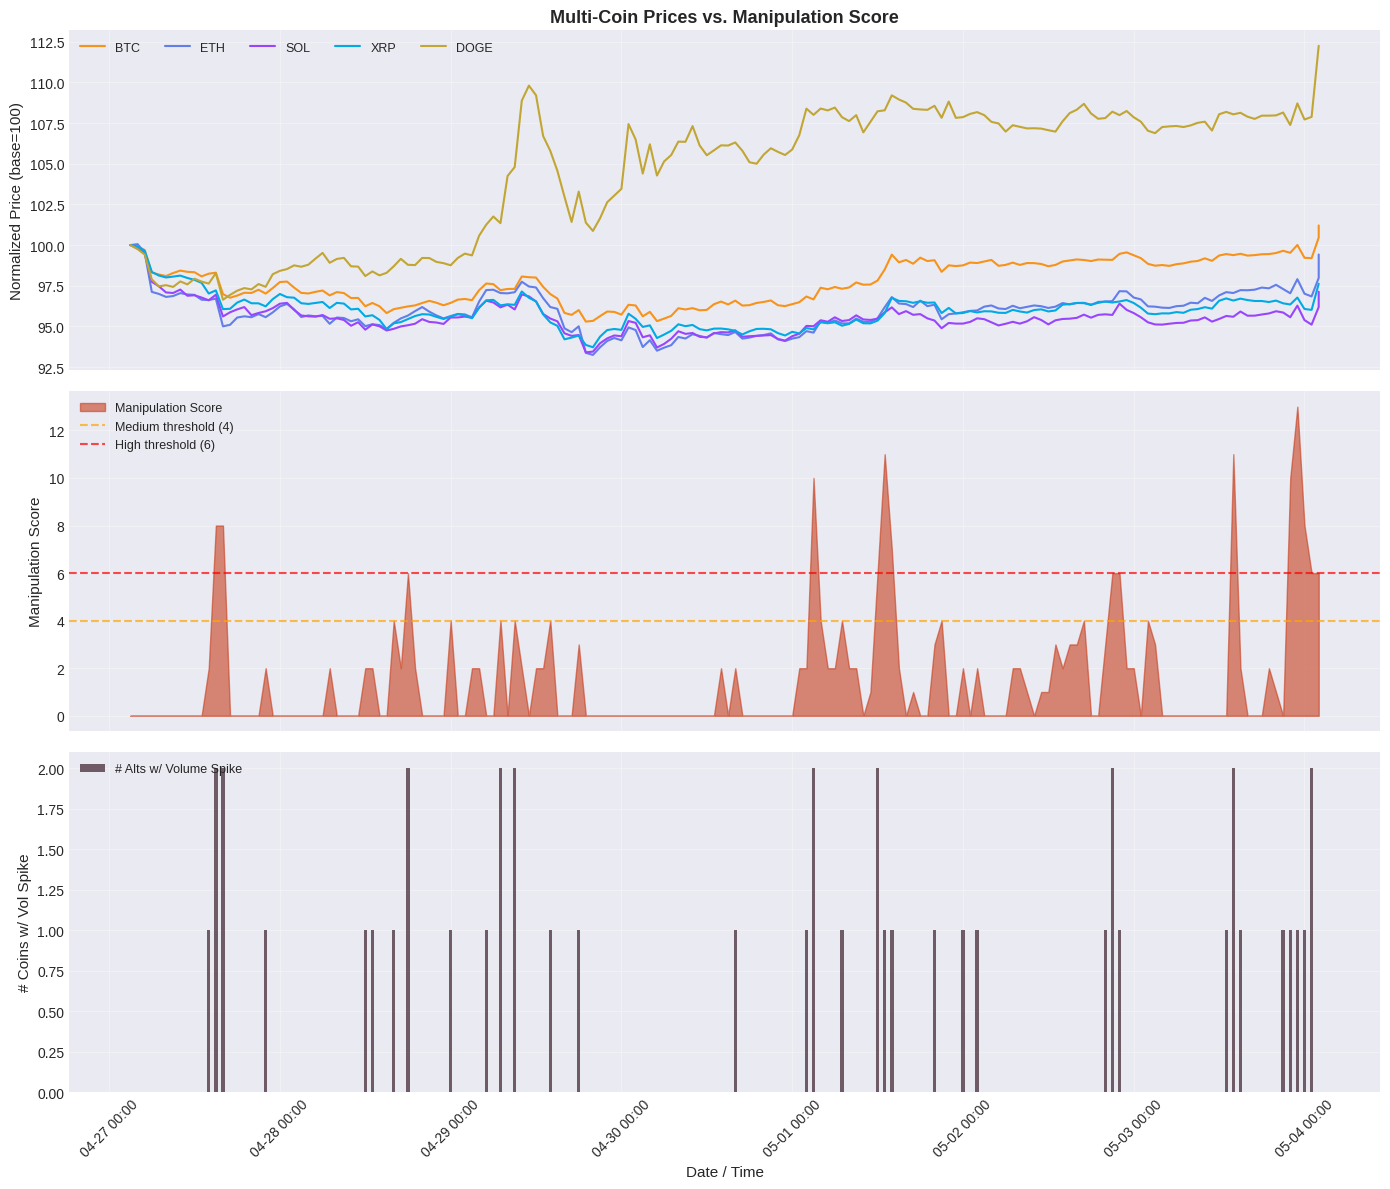

In [72]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ── Panel 1: All coin prices (normalized to 100 at start) ────────────────────
price_cols = {
    'BTC': 'btc_close',
    'ETH': 'eth_close',
    'SOL': 'sol_close',
    'XRP': 'xrp_close',
    'DOGE': 'doge_close',
}
colors = {'BTC': '#F7931A', 'ETH': '#627EEA', 'SOL': '#9945FF', 'XRP': '#00AAE4', 'DOGE': '#C2A633'}

for ticker, col in price_cols.items():
    if col in manipulation_df.columns:
        series = manipulation_df[col].dropna()
        if not series.empty:
            normalized = series / series.iloc[0] * 100
            axes[0].plot(manipulation_df.loc[series.index, 'hour'], normalized,
                         label=ticker, color=colors[ticker], linewidth=1.5)

axes[0].set_ylabel('Normalized Price (base=100)', fontsize=11)
axes[0].set_title('Multi-Coin Prices vs. Manipulation Score', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', ncol=5, fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Panel 2: Manipulation score ───────────────────────────────────────────────
axes[1].fill_between(manipulation_df['hour'], manipulation_df['manipulation_score'],
                     alpha=0.6, color='#C73E1D', label='Manipulation Score')
axes[1].axhline(4, color='orange', linestyle='--', alpha=0.7, label='Medium threshold (4)')
axes[1].axhline(6, color='red',    linestyle='--', alpha=0.7, label='High threshold (6)')
axes[1].set_ylabel('Manipulation Score', fontsize=11)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Panel 3: Alt volume spike count (coordination signal) ────────────────────
axes[2].bar(manipulation_df['hour'], manipulation_df['alt_volume_spike_count'],
            color='#3B1F2B', alpha=0.7, width=0.02, label='# Alts w/ Volume Spike')
axes[2].set_ylabel('# Coins w/ Vol Spike', fontsize=11)
axes[2].set_xlabel('Date / Time', fontsize=11)
axes[2].legend(loc='upper left', fontsize=9)
axes[2].grid(True, alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('multicoin_manipulation_flags.png', dpi=150)
plt.show()


# cross-coin return correlation heatmap

A static correlation matrix over the full 7-day window. When coins that normally have moderate correlation suddenly spike to near-1.0 correlation, that's a flag for coordinated activity (e.g., a bot trading all of them simultaneously).

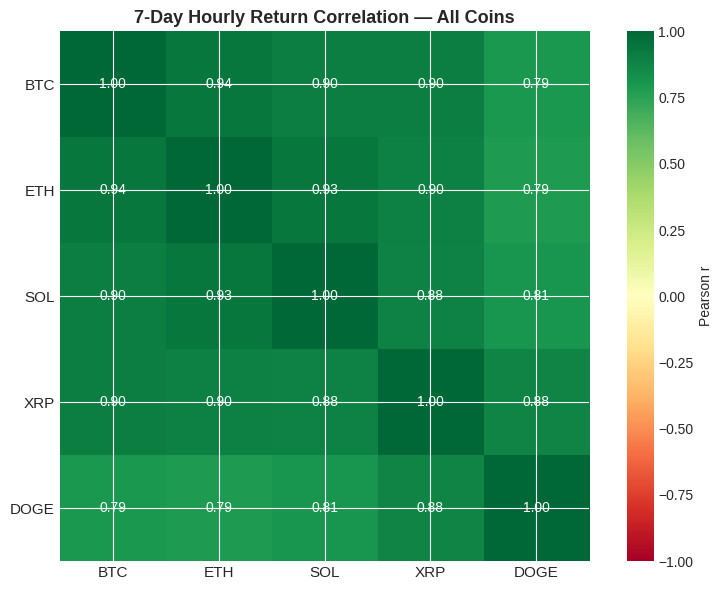

In [73]:
import matplotlib.colors as mcolors

return_cols = [c for c in analysis_df.columns if c.endswith('_return_pct')]
if len(return_cols) >= 2:
    corr_matrix = analysis_df[return_cols].corr()
    # Rename for cleaner labels
    clean_labels = [c.replace('_return_pct', '').upper() for c in return_cols]
    corr_matrix.columns = clean_labels
    corr_matrix.index = clean_labels

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.cm.RdYlGn
    im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label='Pearson r')

    ax.set_xticks(range(len(clean_labels)))
    ax.set_yticks(range(len(clean_labels)))
    ax.set_xticklabels(clean_labels, fontsize=11)
    ax.set_yticklabels(clean_labels, fontsize=11)

    for i in range(len(clean_labels)):
        for j in range(len(clean_labels)):
            ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                    ha='center', va='center', fontsize=10,
                    color='black' if abs(corr_matrix.values[i, j]) < 0.7 else 'white')

    ax.set_title('7-Day Hourly Return Correlation — All Coins', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cross_coin_correlation_heatmap.png', dpi=150)
    plt.show()
else:
    print('Not enough return columns for correlation matrix')


MCP Agent

In [74]:
from mcp.server.fastmcp import FastMCP

# Create the MCP server instance
mcp = FastMCP("CryptoIntelligence")

# correlation analysis

In [75]:
print('CORRELATION ANALYSIS: FinBERT Sentiment vs. Bitcoin Price')
print()

corr_cols = [
    'btc_close',
    'btc_return_pct',
    'reddit_post_count',
    'reddit_avg_sentiment',
    'reddit_weighted_sentiment',
    'reddit_pct_positive',
    'reddit_pct_negative',
    'news_article_count',
    'news_avg_sentiment',
    'news_weighted_sentiment',
    'news_pct_positive',
    'news_pct_negative',
    'news_sources'
]

available = [c for c in corr_cols if c in analysis_df.columns]
corr_table = analysis_df[available].corr()

print(corr_table[['btc_close']].drop('btc_close', errors='ignore').to_string())

CORRELATION ANALYSIS: FinBERT Sentiment vs. Bitcoin Price

                           btc_close
btc_return_pct              0.318299
reddit_post_count           0.677461
reddit_avg_sentiment       -0.420181
reddit_weighted_sentiment  -0.079183
reddit_pct_positive         0.229235
reddit_pct_negative         0.458440
news_article_count          0.248495
news_avg_sentiment          0.024998
news_weighted_sentiment    -0.012747
news_pct_positive           0.214709
news_pct_negative           0.214986
news_sources                0.239482


# PLOTS

plot: btc price vs. reddit weighted (check out how it's weighted) sentiment

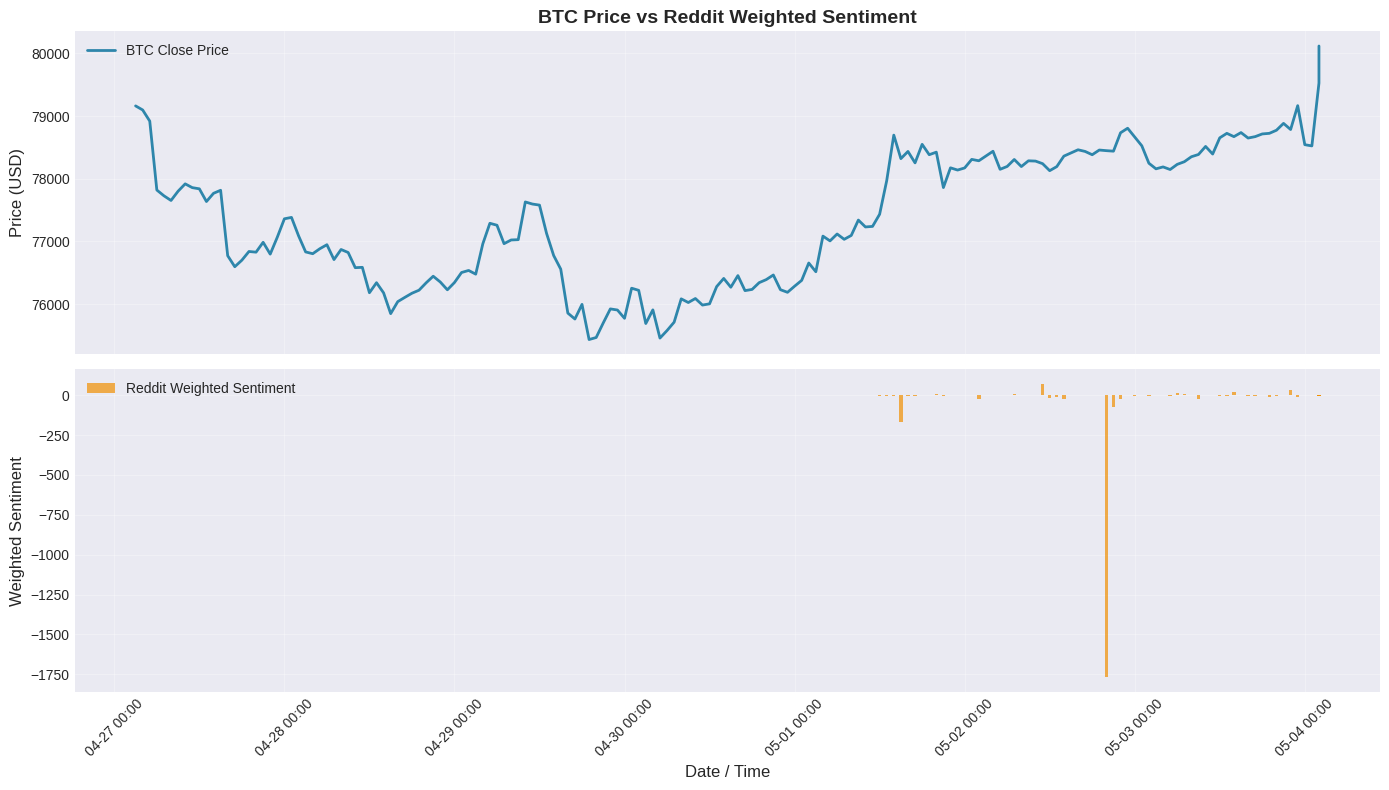

In [76]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(analysis_df['hour'], analysis_df['btc_close'], color='#2E86AB', linewidth=2, label='BTC Close Price')
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].set_title('BTC Price vs Reddit Weighted Sentiment', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].bar(analysis_df['hour'], analysis_df['reddit_weighted_sentiment'], color='#F18F01', alpha=0.7, width=0.02, label='Reddit Weighted Sentiment')
axes[1].set_xlabel('Date / Time', fontsize=12)
axes[1].set_ylabel('Weighted Sentiment', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('btc_vs_reddit_sentiment.png', dpi=150)
plt.show()

plot: btc returns vs. reddit average sentiment

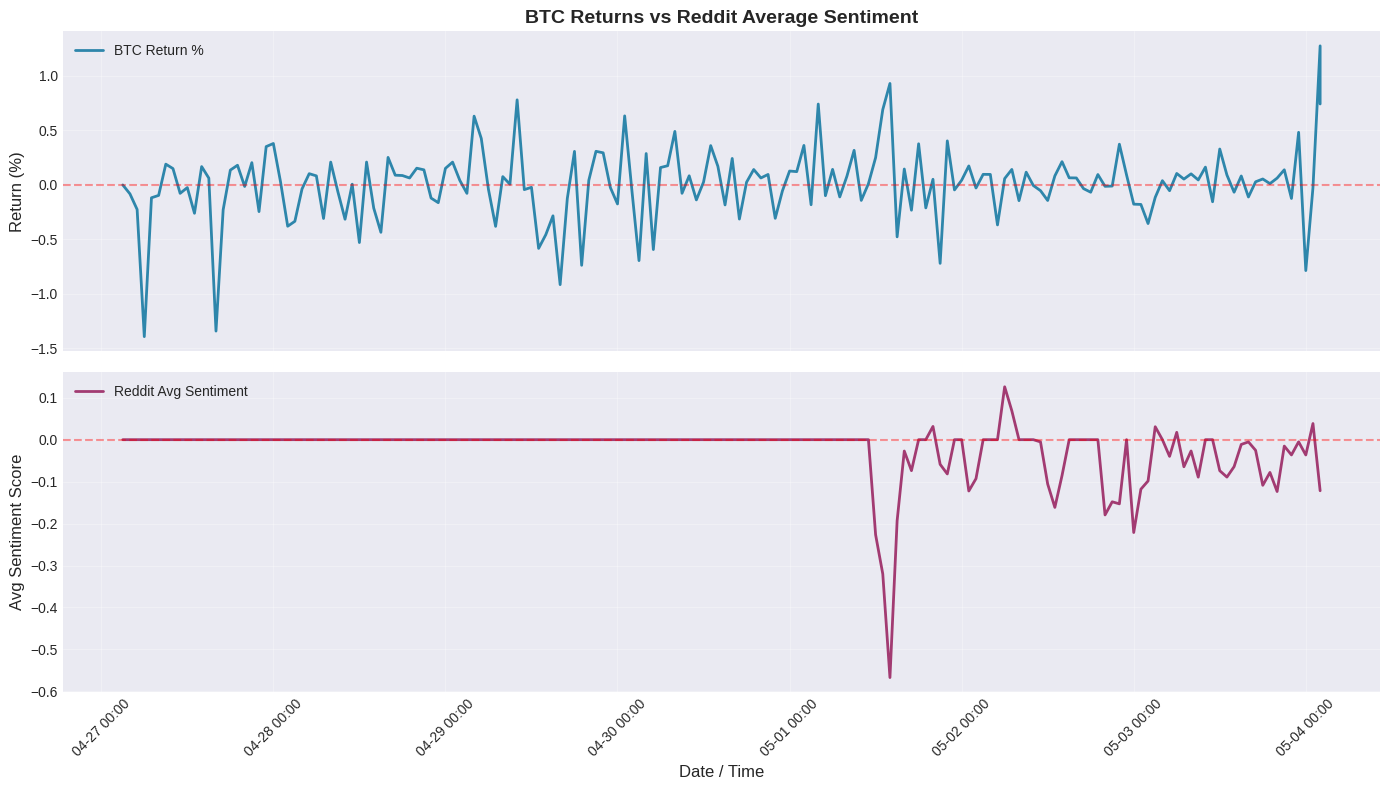

In [77]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(analysis_df['hour'], analysis_df['btc_return_pct'], color='#2E86AB', linewidth=2, label='BTC Return %')
axes[0].set_ylabel('Return (%)', fontsize=12)
axes[0].set_title('BTC Returns vs Reddit Average Sentiment', fontsize=14, fontweight='bold')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.4)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].plot(analysis_df['hour'], analysis_df['reddit_avg_sentiment'], color='#A23B72', linewidth=2, label='Reddit Avg Sentiment')
axes[1].set_xlabel('Date / Time', fontsize=12)
axes[1].set_ylabel('Avg Sentiment Score', fontsize=12)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.4)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('btc_returns_vs_reddit_avg.png', dpi=150)
plt.show()

plot: BTC price vs. News (headlines) sentminet

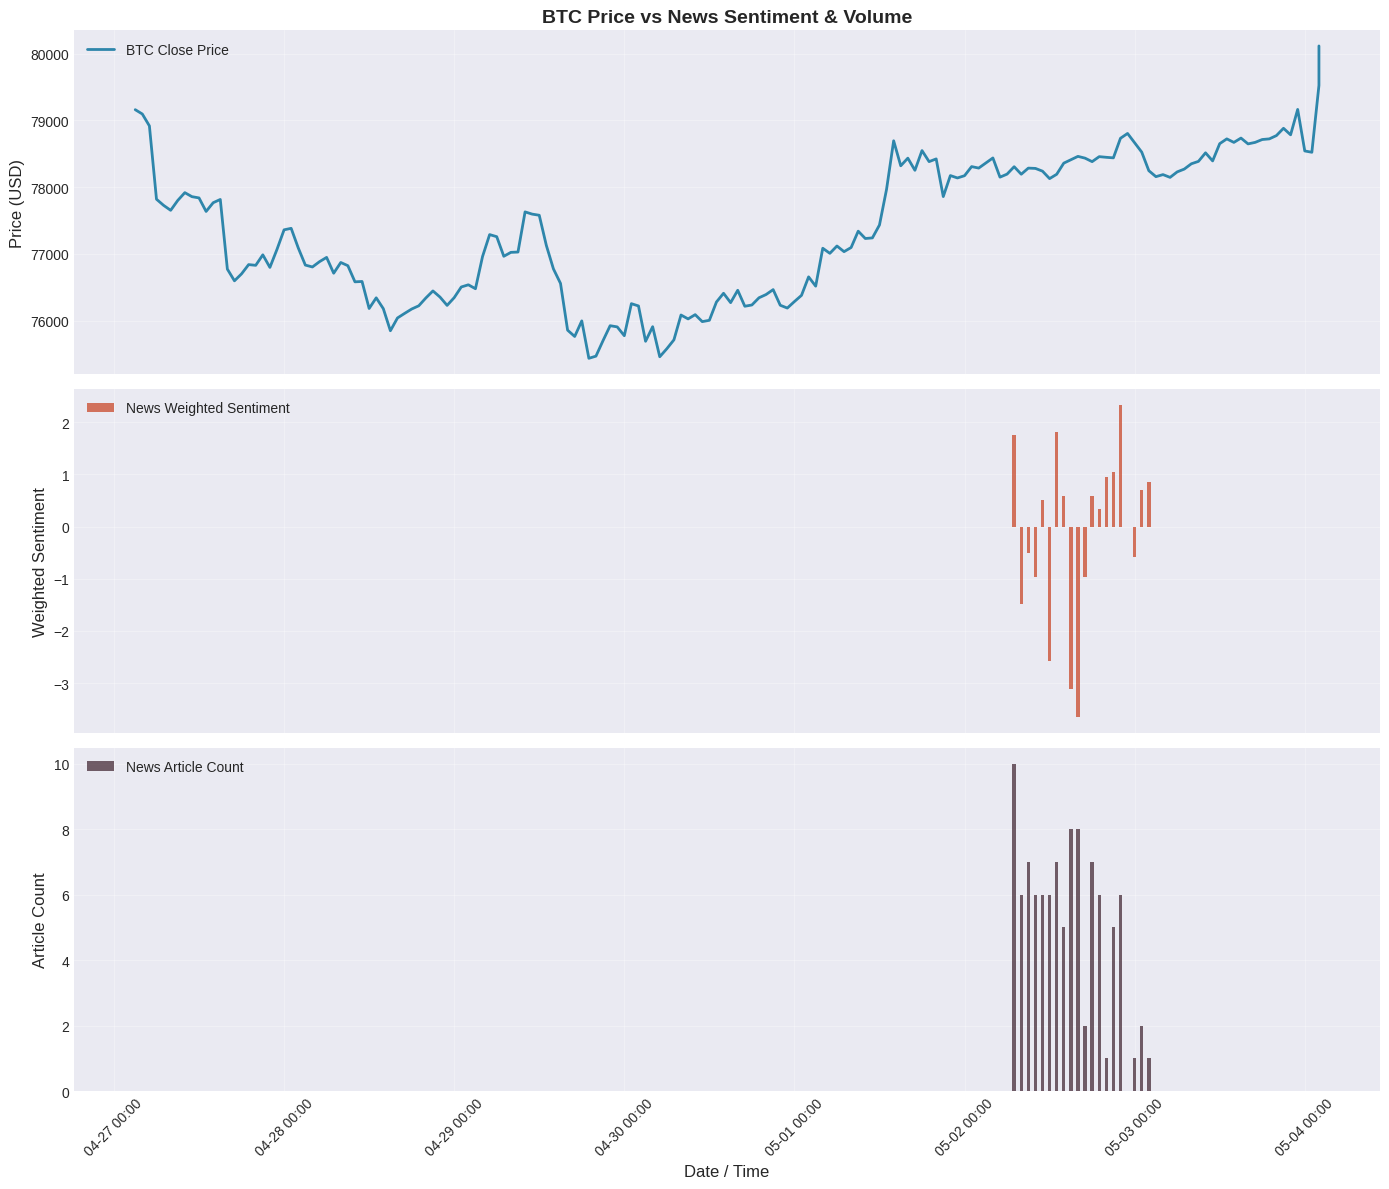

In [78]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(analysis_df['hour'], analysis_df['btc_close'], color='#2E86AB', linewidth=2, label='BTC Close Price')
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].set_title('BTC Price vs News Sentiment & Volume', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].bar(analysis_df['hour'], analysis_df['news_weighted_sentiment'], color='#C73E1D', alpha=0.7, width=0.02, label='News Weighted Sentiment')
axes[1].set_ylabel('Weighted Sentiment', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

axes[2].bar(analysis_df['hour'], analysis_df['news_article_count'], color='#3B1F2B', alpha=0.7, width=0.02, label='News Article Count')
axes[2].set_xlabel('Date / Time', fontsize=12)
axes[2].set_ylabel('Article Count', fontsize=12)
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('btc_vs_news_sentiment.png', dpi=150)
plt.show()

# save all tables to cloud db

each run appends new data and over time we need to build up a real dataset to analyze patterns across


**switch if_exists='replace' to if_exists='append' when we're ready to start accumulating data**

In [79]:
print('Saving all tables to cloud DB...')

tables_to_save = {
    'reddit_raw':            reddit_df,
    'reddit_hourly':         reddit_hourly,
    'btc_hourly':            btc_df,
    'news_raw':              news_df,
    'news_hourly':           news_hourly,
    'master_coin_hourly':    master_df,          # NEW: all 5 coins per hour
    'btc_reddit_analysis':   analysis_df,
    'manipulation_results':  manipulation_df,    # NEW: includes manipulation scores
}

for table_name, df in tables_to_save.items():
    try:
        df_to_save = df.copy()
        for col in df_to_save.select_dtypes(include=['datetimetz']).columns:
            df_to_save[col] = df_to_save[col].dt.tz_localize(None)
        df_to_save.to_sql(table_name, con=engine, if_exists='replace', index=False)
        print(f'  {table_name}: {len(df)} rows saved')
    except Exception as e:
        print(f'  {table_name}: ERROR — {e}')

print('\nAll tables saved to cloud DB')


Saving all tables to cloud DB...
  reddit_raw: ERROR — name 'engine' is not defined
  reddit_hourly: ERROR — name 'engine' is not defined
  btc_hourly: ERROR — name 'engine' is not defined
  news_raw: ERROR — name 'engine' is not defined
  news_hourly: ERROR — name 'engine' is not defined
  master_coin_hourly: ERROR — name 'engine' is not defined
  btc_reddit_analysis: ERROR — name 'engine' is not defined
  manipulation_results: ERROR — name 'engine' is not defined

All tables saved to cloud DB


to verify cloud db tables & preview

In [80]:
"""pd.read_sql('SHOW TABLES', con=engine)"""

"pd.read_sql('SHOW TABLES', con=engine)"

In [81]:
"""pd.read_sql('SELECT * FROM btc_reddit_analysis LIMIT 20', con=engine)"""

"pd.read_sql('SELECT * FROM btc_reddit_analysis LIMIT 20', con=engine)"

## 3 · Frontend — Trading-terminal dashboard

A live page built in **Gradio** on top of `analysis_df` and `manipulation_df`.
The layout takes its cues from professional trading terminals: a ticker strip
on top, a symbol header with the headline price, candlestick + volume on the
main chart, and a status bar pinned to the bottom.

### 3.1 · Theme palette & custom CSS

In [82]:
PALETTE = {
    # TradingView's actual dark palette (classic web app)
    'bg':         '#131722',   # signature TV deep-navy
    'bg_deep':    '#0F121B',   # raised sidebar / footer
    'surface':    '#1E222D',   # panel surfaces
    'elevated':   '#2A2E39',   # raised panels / buttons
    'border':     '#363A45',
    'border_str': '#434651',
    'border_dim': '#252832',
    # Text
    'text':       '#D1D4DC',
    'text_mid':   '#B2B5BE',
    'text_dim':   '#787B86',
    'text_loud':  '#F0F3FA',
    # Brand / accent
    'accent':     '#2962FF',   # TradingView signal blue
    'accent_hi':  '#1E53E5',
    'gold':       '#F7931A',   # BTC mark
    'violet':     '#7B61FF',
    # Semantic
    'bull':       '#26A69A',   # TV teal-green (up)
    'bear':       '#EF5350',   # TV red (down)
    'warn':       '#FF9800',
}

CUSTOM_CSS = f"""
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;600&display=swap');

/* === Base === */
.gradio-container, .gradio-container * {{
    font-family: 'Trebuchet MS', 'Inter', system-ui, -apple-system, 'Helvetica Neue', sans-serif !important;
}}
.gradio-container {{
    background: {PALETTE['bg']} !important;
    color: {PALETTE['text']} !important;
    max-width: 1480px !important;
    padding: 0 !important;
}}
.gradio-container .prose, .gradio-container p, .gradio-container span,
.gradio-container label, .gradio-container .markdown-text {{
    color: {PALETTE['text']} !important;
}}
.gradio-container h1, .gradio-container h2, .gradio-container h3, .gradio-container h4 {{
    color: {PALETTE['text_loud']} !important;
    font-weight: 600;
    letter-spacing: -0.005em;
}}
.tv-num, .num {{
    font-family: 'SF Mono', 'JetBrains Mono', 'IBM Plex Mono', Consolas, monospace !important;
    font-feature-settings: 'tnum' 1, 'zero' 1;
    font-variant-numeric: tabular-nums;
}}
.bull {{ color: {PALETTE['bull']} !important; }}
.bear {{ color: {PALETTE['bear']} !important; }}
.warn {{ color: {PALETTE['warn']} !important; }}
.dim  {{ color: {PALETTE['text_dim']} !important; }}
.mid  {{ color: {PALETTE['text_mid']} !important; }}
.loud {{ color: {PALETTE['text_loud']} !important; }}

/* === Top nav (TV header lockup) === */
.tv-nav {{
    display: flex; align-items: center; gap: 22px;
    padding: 12px 20px;
    background: {PALETTE['bg']};
    border-bottom: 1px solid {PALETTE['border_dim']};
    position: sticky; top: 0; z-index: 50;
}}
.tv-logo {{
    display: flex; align-items: center; gap: 9px;
    font-weight: 700; color: {PALETTE['text_loud']};
    font-size: 15px; letter-spacing: -0.005em;
}}
.tv-logo-mark {{
    width: 26px; height: 26px; border-radius: 7px;
    background: linear-gradient(135deg, {PALETTE['accent']}, #4D7AFF);
    display: inline-flex; align-items: center; justify-content: center;
    box-shadow: 0 4px 14px -6px rgba(41, 98, 255, 0.6);
}}
.tv-nav-links {{ display: flex; align-items: center; gap: 4px; flex: 1; }}
.tv-nav-link {{
    padding: 7px 12px; border-radius: 6px;
    font-size: 13px; font-weight: 500;
    color: {PALETTE['text_mid']};
    transition: background 120ms ease, color 120ms ease;
    cursor: default;
}}
.tv-nav-link:hover {{
    background: {PALETTE['surface']};
    color: {PALETTE['text_loud']};
}}
.tv-nav-link.active {{ color: {PALETTE['text_loud']}; }}
.tv-nav-search {{
    display: flex; align-items: center; gap: 8px;
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border']};
    border-radius: 6px;
    padding: 7px 12px; min-width: 220px;
    color: {PALETTE['text_dim']}; font-size: 12px;
}}
.tv-nav-cta {{
    background: {PALETTE['accent']};
    color: white; padding: 8px 14px; border-radius: 6px;
    font-size: 12px; font-weight: 600;
    transition: background 120ms ease, transform 100ms ease;
    cursor: default;
}}
.tv-nav-cta:hover {{ background: {PALETTE['accent_hi']}; transform: translateY(-1px); }}

/* === Breadcrumb === */
.crumb {{
    padding: 14px 20px 0;
    font-size: 11px; color: {PALETTE['text_dim']};
    letter-spacing: 0.005em;
}}
.crumb-cur {{ color: {PALETTE['text_loud']}; font-weight: 500; }}
.crumb-sep {{ margin: 0 6px; color: {PALETTE['border_str']}; }}

/* === Symbol bar (sticky-ish header for the page) === */
.symbol-bar {{
    display: flex; align-items: center; justify-content: space-between;
    gap: 18px; padding: 4px 20px 18px; flex-wrap: wrap;
}}
.symbol-left {{ display: flex; align-items: center; gap: 14px; flex-wrap: wrap; }}
.symbol-chip {{
    width: 38px; height: 38px; border-radius: 50%;
    display: flex; align-items: center; justify-content: center;
    font-weight: 700; font-size: 20px; color: #FFFFFF;
    background: linear-gradient(135deg, {PALETTE['gold']}, #C97A0A);
    box-shadow: 0 1px 0 rgba(255,255,255,0.18) inset, 0 6px 16px -8px rgba(247, 147, 26, 0.55);
}}
.symbol-name {{
    font-size: 17px; font-weight: 600; color: {PALETTE['text_loud']};
    letter-spacing: -0.005em; line-height: 1.15;
}}
.symbol-sub {{
    font-size: 11px; color: {PALETTE['text_dim']};
    letter-spacing: 0.04em; margin-top: 3px; font-weight: 500;
}}

/* === Section header (TV "Title ›") === */
.section-head {{
    display: flex; align-items: center; gap: 10px;
    margin: 24px 4px 12px;
}}
.section-label {{
    font-size: 24px; font-weight: 600; color: {PALETTE['text_loud']};
    letter-spacing: -0.012em;
}}
.section-chev {{
    color: {PALETTE['text_dim']};
    font-size: 24px; line-height: 1; font-weight: 400;
    transition: transform 140ms ease, color 140ms ease;
    cursor: default;
}}
.section-head:hover .section-chev {{
    color: {PALETTE['accent']}; transform: translateX(3px);
}}
.section-sub {{
    margin-left: auto; font-size: 11px; color: {PALETTE['text_dim']};
    font-weight: 500; letter-spacing: 0.02em;
}}
.page-pad {{ padding: 0 20px; }}

/* === Sub-tab pill row (TV "Popular | Recent | Video") === */
.tab-pills {{ display: flex; gap: 6px; margin: 4px 0 14px; }}
.tab-pill {{
    padding: 6px 14px; border-radius: 999px;
    font-size: 13px; font-weight: 500;
    color: {PALETTE['text_mid']};
    background: transparent;
    border: 1px solid transparent;
    cursor: default;
    transition: background 120ms ease, color 120ms ease, border-color 120ms ease;
}}
.tab-pill:hover {{
    background: {PALETTE['surface']};
    color: {PALETTE['text_loud']};
}}
.tab-pill.active {{
    background: {PALETTE['elevated']};
    color: {PALETTE['text_loud']};
    border-color: {PALETTE['border']};
}}

/* === Filter chip row === */
.chip-row {{
    display: flex; flex-wrap: wrap; gap: 6px;
    margin: 8px 0 14px;
}}
.chip {{
    padding: 6px 12px; border-radius: 999px;
    font-size: 12px; font-weight: 500;
    color: {PALETTE['text_mid']};
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    cursor: default;
    transition: all 120ms ease;
}}
.chip:hover {{
    background: {PALETTE['elevated']};
    color: {PALETTE['text_loud']};
    border-color: {PALETTE['border']};
}}
.chip.active {{
    background: {PALETTE['elevated']};
    color: {PALETTE['text_loud']};
    border-color: {PALETTE['accent']};
}}

/* === Pills (price change) === */
.pill {{
    display: inline-flex; align-items: center; gap: 4px;
    padding: 4px 9px; border-radius: 6px;
    font-size: 12px; font-weight: 600; line-height: 1;
    font-family: 'SF Mono', 'JetBrains Mono', monospace;
    font-variant-numeric: tabular-nums;
}}
.pill.bull {{ background: rgba(38, 166, 154, 0.13); color: {PALETTE['bull']} !important; }}
.pill.bear {{ background: rgba(239, 83, 80, 0.13); color: {PALETTE['bear']} !important; }}
.pill.warn {{ background: rgba(255, 152, 0, 0.13); color: {PALETTE['warn']} !important; }}
.pill.neutral {{ background: rgba(178, 181, 190, 0.10); color: {PALETTE['text_mid']} !important; }}

/* === Market summary 2-up (TV crypto-overview pattern) === */
.market-2up {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 0;
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    border-radius: 8px;
    overflow: hidden;
}}
@media (max-width: 760px) {{ .market-2up {{ grid-template-columns: 1fr; }} }}
.market-cell {{
    padding: 18px 20px;
    border-right: 1px solid {PALETTE['border_dim']};
}}
.market-cell:last-child {{ border-right: 0; }}
.market-cell-label {{
    font-size: 11px; color: {PALETTE['text_dim']};
    font-weight: 500; letter-spacing: 0.02em;
    text-transform: capitalize;
    display: flex; align-items: center; gap: 8px;
}}
.market-cell-tag {{
    font-size: 9px; font-weight: 700;
    padding: 2px 6px; border-radius: 3px;
    background: {PALETTE['elevated']}; color: {PALETTE['text_dim']};
    text-transform: uppercase; letter-spacing: 0.06em;
}}
.market-cell-value {{
    font-size: 28px; font-weight: 600; color: {PALETTE['text_loud']};
    margin-top: 8px; line-height: 1; letter-spacing: -0.012em;
}}
.market-cell-row {{ display: flex; align-items: baseline; gap: 10px; margin-top: 6px; }}
.market-cell-spark {{ margin-top: 12px; }}
.market-cell-spark svg {{ width: 100%; height: 64px; display: block; }}
.market-cell-axis {{
    display: flex; justify-content: space-between;
    margin-top: 4px; font-size: 9px; color: {PALETTE['text_dim']};
    font-family: 'SF Mono', monospace;
}}

/* === Movers grid (TV "Major indices") === */
.movers-grid {{
    display: grid;
    grid-template-columns: repeat(2, minmax(0, 1fr));
    gap: 8px;
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    border-radius: 8px;
    padding: 8px;
}}
@media (min-width: 900px) {{
    .movers-grid {{ grid-template-columns: repeat(4, minmax(0, 1fr)); }}
}}
.mover-card {{
    padding: 12px 14px;
    border-radius: 6px;
    transition: background 120ms ease;
    cursor: default;
    border: 1px solid transparent;
}}
.mover-card:hover {{
    background: {PALETTE['elevated']};
    border-color: {PALETTE['border']};
}}
.mover-name {{
    font-size: 12px; font-weight: 600; color: {PALETTE['text_loud']};
}}
.mover-sub {{
    font-size: 10px; color: {PALETTE['text_dim']};
    text-transform: uppercase; letter-spacing: 0.06em;
    margin-top: 2px;
}}
.mover-row {{
    display: flex; align-items: center;
    justify-content: space-between; gap: 12px;
    margin-top: 10px;
}}
.mover-value {{
    font-size: 15px; font-weight: 600; color: {PALETTE['text_loud']};
    font-family: 'SF Mono', monospace; font-variant-numeric: tabular-nums;
    letter-spacing: -0.005em;
}}
.mover-spark {{ flex-shrink: 0; }}

/* === Community trends (chip-card row) === */
.community-trends {{
    display: grid;
    grid-template-columns: repeat(auto-fill, minmax(220px, 1fr));
    gap: 8px;
}}
.community-card {{
    display: flex; align-items: center; gap: 12px;
    padding: 12px 14px;
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    border-radius: 8px;
    transition: border-color 120ms ease, background 120ms ease;
    cursor: default;
}}
.community-card:hover {{
    border-color: {PALETTE['border']};
    background: {PALETTE['elevated']};
}}
.community-mark {{
    width: 32px; height: 32px; border-radius: 50%;
    display: flex; align-items: center; justify-content: center;
    font-size: 14px; font-weight: 700; color: white;
    flex-shrink: 0;
}}
.community-info {{ flex: 1; min-width: 0; }}
.community-name {{
    font-size: 13px; font-weight: 600; color: {PALETTE['text_loud']};
    line-height: 1.1;
}}
.community-sub {{
    font-size: 10px; color: {PALETTE['text_dim']};
    text-transform: uppercase; letter-spacing: 0.06em;
    margin-top: 3px;
}}
.community-val {{
    font-family: 'SF Mono', monospace; font-size: 13px;
    font-weight: 600; text-align: right;
    line-height: 1.1;
}}
.community-pct {{
    font-family: 'SF Mono', monospace; font-size: 10px;
    text-align: right; margin-top: 2px;
}}

/* === Gainers/losers list === */
.gl-grid {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 12px;
}}
@media (max-width: 760px) {{ .gl-grid {{ grid-template-columns: 1fr; }} }}
.gl-card {{
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    border-radius: 8px;
    overflow: hidden;
}}
.gl-card-head {{
    padding: 10px 14px;
    background: {PALETTE['elevated']};
    border-bottom: 1px solid {PALETTE['border_dim']};
    font-size: 11px; font-weight: 600;
    text-transform: uppercase; letter-spacing: 0.06em;
    color: {PALETTE['text_loud']};
    display: flex; justify-content: space-between; align-items: center;
}}
.gl-row {{
    display: grid;
    grid-template-columns: 24px 1fr auto;
    gap: 12px; align-items: center;
    padding: 10px 14px;
    border-bottom: 1px solid {PALETTE['border_dim']};
    transition: background 120ms ease;
}}
.gl-row:last-child {{ border-bottom: 0; }}
.gl-row:hover {{ background: {PALETTE['elevated']}; }}
.gl-rank {{
    font-size: 11px; color: {PALETTE['text_dim']}; font-weight: 500;
    font-family: 'SF Mono', monospace;
}}
.gl-when {{ font-size: 13px; color: {PALETTE['text_loud']}; font-weight: 500; }}
.gl-meta {{
    font-size: 10px; color: {PALETTE['text_dim']};
    text-transform: uppercase; letter-spacing: 0.06em;
    margin-top: 2px;
    font-family: 'SF Mono', monospace; font-variant-numeric: tabular-nums;
}}
.gl-pct {{
    font-family: 'SF Mono', monospace;
    font-size: 13px; font-weight: 600;
    padding: 4px 8px; border-radius: 4px;
    text-align: right;
}}
.gl-pct.bull {{ background: rgba(38, 166, 154, 0.13); }}
.gl-pct.bear {{ background: rgba(239, 83, 80, 0.13); }}

/* === Feed (news / alerts) === */
.feed-list {{
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    border-radius: 8px;
    overflow: hidden;
}}
.feed-item {{
    display: grid;
    grid-template-columns: auto 1fr auto;
    gap: 14px; align-items: center;
    padding: 12px 16px;
    border-bottom: 1px solid {PALETTE['border_dim']};
    transition: background 120ms ease;
    cursor: default;
}}
.feed-item:last-child {{ border-bottom: 0; }}
.feed-item:hover {{ background: {PALETTE['elevated']}; }}
.feed-time {{
    font-family: 'SF Mono', monospace; font-size: 11px;
    color: {PALETTE['text_dim']}; min-width: 96px;
}}
.feed-headline {{
    font-size: 13px; color: {PALETTE['text_loud']}; font-weight: 500;
    line-height: 1.45;
}}
.feed-meta {{
    font-size: 10px; color: {PALETTE['text_dim']};
    text-transform: uppercase; letter-spacing: 0.06em;
    margin-top: 3px;
}}
.feed-score {{
    font-family: 'SF Mono', monospace; font-size: 12px;
    font-weight: 600; padding: 4px 9px; border-radius: 4px;
    white-space: nowrap;
}}
.feed-empty {{
    padding: 32px; text-align: center;
    color: {PALETTE['text_dim']}; font-size: 13px;
}}
.feed-empty-emoji {{ font-size: 26px; display: block; margin-bottom: 8px; }}

/* === KPI mini-cards (sparkline summary) === */
.kpi-grid {{
    display: grid;
    grid-template-columns: repeat(2, minmax(0, 1fr));
    gap: 8px;
}}
@media (min-width: 900px) {{ .kpi-grid {{ grid-template-columns: repeat(4, minmax(0, 1fr)); }} }}
.kpi-card {{
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    border-radius: 8px;
    padding: 14px 16px 12px;
    transition: border-color 140ms ease, background 140ms ease;
}}
.kpi-card:hover {{
    border-color: {PALETTE['border']};
    background: {PALETTE['elevated']};
}}
.kpi-top {{
    display: flex; justify-content: space-between; align-items: flex-start;
    gap: 10px; margin-bottom: 10px;
}}
.kpi-label {{
    font-size: 11px; color: {PALETTE['text_dim']};
    text-transform: uppercase; letter-spacing: 0.06em; font-weight: 500;
    line-height: 1.3;
}}
.kpi-bottom {{ display: flex; align-items: baseline; gap: 8px; flex-wrap: wrap; }}
.kpi-value {{
    font-size: 22px; font-weight: 600;
    letter-spacing: -0.01em; line-height: 1;
    font-family: 'SF Mono', monospace;
}}
.kpi-delta {{ font-size: 11px; color: {PALETTE['text_dim']}; }}

/* === FAQ accordion === */
.faq {{
    background: {PALETTE['surface']};
    border: 1px solid {PALETTE['border_dim']};
    border-radius: 8px;
    overflow: hidden;
}}
.faq-item {{
    border-bottom: 1px solid {PALETTE['border_dim']};
}}
.faq-item:last-child {{ border-bottom: 0; }}
.faq-item summary {{
    list-style: none;
    padding: 14px 16px;
    cursor: pointer;
    display: flex; justify-content: space-between; align-items: center;
    font-size: 13px; font-weight: 500;
    color: {PALETTE['text_loud']};
    transition: background 120ms ease;
}}
.faq-item summary::-webkit-details-marker {{ display: none; }}
.faq-item summary:hover {{ background: {PALETTE['elevated']}; }}
.faq-item summary::after {{
    content: '+';
    font-family: 'SF Mono', monospace;
    color: {PALETTE['text_dim']}; font-size: 18px;
    font-weight: 400;
    transition: transform 200ms ease;
}}
.faq-item[open] summary::after {{ content: '−'; }}
.faq-item[open] summary {{ background: {PALETTE['elevated']}; }}
.faq-a {{
    padding: 4px 16px 16px;
    font-size: 12px; line-height: 1.55;
    color: {PALETTE['text_mid']};
}}

/* === Block/panel surfaces === */
.gradio-container .block, .gradio-container .form, .gradio-container .panel,
.gradio-container .gr-block, .gradio-container .gr-form, .gradio-container .gr-panel {{
    background: transparent !important;
    border-color: {PALETTE['border_dim']} !important;
    color: {PALETTE['text']} !important;
}}

/* === Plotly containers === */
.gradio-container .plot, .gradio-container .gr-plot,
.gradio-container .js-plotly-plot, .gradio-container .plotly,
.gradio-container .plot-container {{
    background: transparent !important;
}}
.gradio-container .plot, .gradio-container .gr-plot {{
    border: 1px solid {PALETTE['border_dim']} !important;
    border-radius: 8px !important;
    padding: 8px !important;
    background: {PALETTE['surface']} !important;
}}

/* === Inputs === */
.gradio-container input, .gradio-container textarea, .gradio-container select {{
    background: {PALETTE['elevated']} !important;
    color: {PALETTE['text_loud']} !important;
    border: 1px solid {PALETTE['border']} !important;
    border-radius: 6px !important;
}}
.gradio-container input::placeholder, .gradio-container textarea::placeholder {{
    color: {PALETTE['text_dim']} !important;
}}
.gradio-container input:focus, .gradio-container textarea:focus {{
    border-color: {PALETTE['accent']} !important;
    box-shadow: 0 0 0 3px rgba(41, 98, 255, 0.18) !important;
}}

/* === Top-level tabs (TV "Stocks | Crypto market" pattern) === */
.gradio-container .tab-nav, .gradio-container [class*='tab-nav'] {{
    border-bottom: 1px solid {PALETTE['border_dim']} !important;
    background: {PALETTE['bg']} !important;
    padding: 0 20px !important;
    gap: 0 !important;
}}
.gradio-container button[role='tab'] {{
    color: {PALETTE['text_dim']} !important;
    background: transparent !important;
    font-weight: 500 !important;
    font-size: 13px !important;
    padding: 12px 14px !important;
    border: 0 !important;
    border-bottom: 2px solid transparent !important;
    border-radius: 0 !important;
    transition: color 140ms ease, border-color 140ms ease;
}}
.gradio-container button[role='tab']:hover {{ color: {PALETTE['text']} !important; }}
.gradio-container button[role='tab'][aria-selected='true'] {{
    color: {PALETTE['text_loud']} !important;
    border-bottom-color: {PALETTE['accent']} !important;
}}

/* === Tables === */
.gradio-container .table-wrap, .gradio-container .table-wrap *,
.gradio-container [class*='dataframe'], .gradio-container [class*='dataframe'] *,
.gradio-container [data-testid*='dataframe'], .gradio-container [data-testid*='dataframe'] *,
.gradio-container .cell-wrap {{
    background-color: {PALETTE['surface']} !important;
    color: {PALETTE['text']} !important;
    border-color: {PALETTE['border_dim']} !important;
    font-family: 'SF Mono', 'JetBrains Mono', monospace !important;
    font-size: 12px !important;
}}
.gradio-container th, .gradio-container thead, .gradio-container thead * {{
    background-color: {PALETTE['elevated']} !important;
    color: {PALETTE['text_dim']} !important;
    text-transform: uppercase;
    letter-spacing: 0.06em;
    font-weight: 500 !important;
    font-size: 10px !important;
    font-family: 'Trebuchet MS', sans-serif !important;
}}
.gradio-container tbody tr:hover td {{ background-color: {PALETTE['elevated']} !important; }}

/* === Buttons === */
.gradio-container button:not([role='tab']) {{
    transition: transform 100ms ease, background 100ms ease, box-shadow 120ms ease !important;
    border-radius: 6px !important;
    font-weight: 500 !important;
    font-size: 12px !important;
}}
.gradio-container button:not([role='tab']):hover {{ transform: translateY(-1px); }}
.gradio-container button:focus-visible {{
    outline: 2px solid {PALETTE['accent']} !important;
    outline-offset: 2px;
}}
.gradio-container button.primary, .gradio-container button[variant='primary'] {{
    background: {PALETTE['accent']} !important;
    color: white !important;
    border: 0 !important;
}}
.gradio-container button.primary:hover, .gradio-container button[variant='primary']:hover {{
    background: {PALETTE['accent_hi']} !important;
}}

/* === Sliders === */
.gradio-container input[type='range'] {{ accent-color: {PALETTE['accent']} !important; }}

/* === Scrollbar === */
.gradio-container ::-webkit-scrollbar {{ width: 10px; height: 10px; }}
.gradio-container ::-webkit-scrollbar-track {{ background: {PALETTE['bg']}; }}
.gradio-container ::-webkit-scrollbar-thumb {{
    background: {PALETTE['elevated']};
    border-radius: 5px;
    border: 2px solid {PALETTE['bg']};
}}
.gradio-container ::-webkit-scrollbar-thumb:hover {{ background: {PALETTE['border_str']}; }}

/* === Status bar === */
.status-bar {{
    display: flex; align-items: center; gap: 14px; flex-wrap: wrap;
    padding: 10px 20px;
    margin-top: 22px;
    background: {PALETTE['bg_deep']};
    border-top: 1px solid {PALETTE['border_dim']};
    color: {PALETTE['text_dim']}; font-size: 11px;
    font-family: 'SF Mono', 'JetBrains Mono', monospace;
}}
.status-dot {{
    width: 7px; height: 7px; border-radius: 50%;
    background: {PALETTE['bull']}; display: inline-block;
    margin-right: 6px;
    box-shadow: 0 0 0 0 rgba(38, 166, 154, 0.5);
    animation: pulse 2.4s infinite;
}}
@keyframes pulse {{
    0%   {{ box-shadow: 0 0 0 0 rgba(38, 166, 154, 0.45); }}
    70%  {{ box-shadow: 0 0 0 7px rgba(38, 166, 154, 0); }}
    100% {{ box-shadow: 0 0 0 0 rgba(38, 166, 154, 0); }}
}}
.status-sep {{ color: {PALETTE['border_str']}; }}

/* === Lab card === */
.lab-card {{
    padding: 18px 20px;
    border: 1px solid {PALETTE['border_dim']};
    border-left: 3px solid {PALETTE['accent']};
    background: {PALETTE['surface']};
    border-radius: 6px;
}}
.lab-card.bull    {{ border-left-color: {PALETTE['bull']} !important; }}
.lab-card.bear    {{ border-left-color: {PALETTE['bear']} !important; }}
.lab-card.neutral {{ border-left-color: {PALETTE['text_dim']} !important; }}
"""

THEME = gr.themes.Base(
    primary_hue='blue',
    neutral_hue='slate',
    font=[gr.themes.GoogleFont('Inter'), 'Trebuchet MS', 'system-ui', 'sans-serif'],
).set(
    body_background_fill=PALETTE['bg'],
    body_text_color=PALETTE['text'],
    body_text_color_subdued=PALETTE['text_dim'],
    background_fill_primary=PALETTE['bg'],
    background_fill_secondary=PALETTE['surface'],
    border_color_primary=PALETTE['border_dim'],
    block_background_fill='transparent',
    block_border_color=PALETTE['border_dim'],
    block_label_background_fill='transparent',
    block_label_text_color=PALETTE['text_dim'],
    block_title_text_color=PALETTE['text_loud'],
    panel_background_fill='transparent',
    button_primary_background_fill=PALETTE['accent'],
    button_primary_background_fill_hover=PALETTE['accent_hi'],
    button_primary_text_color='#FFFFFF',
    button_secondary_background_fill=PALETTE['elevated'],
    button_secondary_text_color=PALETTE['text_loud'],
    input_background_fill=PALETTE['elevated'],
    input_border_color=PALETTE['border'],
    color_accent=PALETTE['accent'],
    color_accent_soft=PALETTE['accent'],
)
print('TradingView dark theme defined.')

TradingView dark theme defined.


### 3.2 · Plotly figure builders (TV-style charts)

In [83]:
def tv_layout(title='', height=420, **extra):
    base = dict(
        title=dict(text=title, font=dict(family='Inter', size=12, color=PALETTE['text_dim']), x=0.01, xanchor='left'),
        height=height,
        margin=dict(l=8, r=56, t=28, b=8),
        paper_bgcolor='rgba(0, 0, 0, 0)',
        plot_bgcolor='rgba(0, 0, 0, 0)',
        font=dict(family='Inter', color=PALETTE['text'], size=11),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1,
                    bgcolor='rgba(0,0,0,0)', font=dict(color=PALETTE['text_dim'], size=10)),
        xaxis=dict(
            gridcolor='rgba(255, 255, 255, 0.05)', linecolor='rgba(255, 255, 255, 0.1)', zeroline=False,
            showspikes=True, spikecolor=PALETTE['text_dim'], spikethickness=1,
            spikedash='dot', spikemode='across', tickfont=dict(family='JetBrains Mono', size=10, color=PALETTE['text_dim']),
        ),
        yaxis=dict(
            gridcolor='rgba(255, 255, 255, 0.05)', linecolor='rgba(255, 255, 255, 0.1)', zeroline=False,
            side='right', tickfont=dict(family='JetBrains Mono', size=10, color=PALETTE['text_dim']),
        ),
        hoverlabel=dict(
            bgcolor=PALETTE['elevated'], bordercolor='rgba(255, 255, 255, 0.15)',
            font=dict(family='JetBrains Mono', size=11, color=PALETTE['text_loud']),
        ),
        hovermode='x unified',
        dragmode='pan',
    )
    base.update(extra)
    return base


def fig_candles_volume(df, ticker):
    """Main price chart: candlesticks (if OHLC available) + volume bars below."""
    close_col = f'{ticker.lower()}_close'
    volume_col = f'{ticker.lower()}_volume'

    # Ensure OHLC columns exist, otherwise fallback to close price only
    ohlc_cols = [f'{ticker.lower()}_open', f'{ticker.lower()}_high', f'{ticker.lower()}_low']
    has_ohlc = all(c in df.columns for c in ohlc_cols)

    # Fallback to generic if specific ticker columns are not found (e.g., for BTC, which might use 'close')
    current_close_col = close_col if close_col in df.columns else 'close'
    current_volume_col = volume_col if volume_col in df.columns else 'volume'

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02,
        row_heights=[0.74, 0.26],
        subplot_titles=('', ''),
    )

    if has_ohlc:
        # Assuming open, high, low, close are named like btc_open, btc_high, etc.
        open_col, high_col, low_col = ohlc_cols[0], ohlc_cols[1], ohlc_cols[2]
        candle_hover = [
            f"<b>{pd.Timestamp(ts).strftime('%b %d %H:%M')}</b>"
            f"<br>O {o:,.2f}  H {h:,.2f}"
            f"<br>L {l:,.2f}  C {c:,.2f}"
            for ts, o, h, l, c in zip(df['hour'], df[open_col], df[high_col], df[low_col], df[current_close_col])
        ]
        fig.add_trace(go.Candlestick(
            x=df['hour'], open=df[open_col], high=df[high_col], low=df[low_col], close=df[current_close_col],
            name=f'{ticker}/USD',
            increasing=dict(line=dict(color=PALETTE['bull'], width=1), fillcolor=PALETTE['bull']),
            decreasing=dict(line=dict(color=PALETTE['bear'], width=1), fillcolor=PALETTE['bear']),
            whiskerwidth=0.4,
            hovertext=candle_hover,
            hoverinfo='text',
        ), row=1, col=1)
    else:
        fig.add_trace(go.Scatter(
            x=df['hour'], y=df[current_close_col], name=f'{ticker}/USD',
            line=dict(color=PALETTE['accent'], width=1.5),
            fill='none', fillcolor=f'rgba({int(COIN_METADATA[ticker]["color"][1:3], 16)}, {int(COIN_METADATA[ticker]["color"][3:5], 16)}, {int(COIN_METADATA[ticker]["color"][5:7], 16)}, 0.10)', # Use coin-specific color
            hovertemplate='<b>%{x|%b %d %H:%M}</b><br>%{y:,.2f}<extra></extra>',
        ), row=1, col=1)

    # Volume colored by candle direction (or daily return sign)
    # Use coin-specific close if available, otherwise fallback to generic 'close'
    if current_close_col in df.columns:
        if has_ohlc: # If OHLC data is available, use open from OHLC
            direction = (df[current_close_col] - df[ohlc_cols[0]])
        else: # Otherwise, use previous close for direction
            direction = (df[current_close_col] - df[current_close_col].shift(1).fillna(df[current_close_col]))
        vol_colors = [PALETTE['bull'] if d >= 0 else PALETTE['bear'] for d in direction]
    else:
        vol_colors = PALETTE['accent'] # Default color if no price data for direction

    fig.add_trace(go.Bar(
        x=df['hour'], y=df[current_volume_col], name='Volume',
        marker=dict(color=vol_colors, line=dict(width=0)),
        opacity=0.55,
        hovertemplate='<b>%{x|%b %d %H:%M}</b><br>Vol %{y:,.0f}<extra></extra>',
    ), row=2, col=1)

    fig.update_layout(**tv_layout('', height=520, showlegend=False, xaxis_rangeslider_visible=False))
    fig.update_yaxes(title_text='', row=1, col=1, gridcolor='rgba(255, 255, 255, 0.05)', side='right')
    fig.update_yaxes(title_text='', row=2, col=1, gridcolor='rgba(255, 255, 255, 0.05)', side='right',
                     tickfont=dict(family='JetBrains Mono', size=9, color=PALETTE['text_dim']))
    fig.update_xaxes(rangeslider_visible=False, showspikes=True)
    return fig


def fig_sentiment_study(df, sources, metric, ticker):
    """TV-style indicator panels: price on top, sentiment 'study' below."""
    metric_col = 'weighted_sentiment' if metric == 'Weighted by activity' else 'avg_sentiment'
    close_col = f'{ticker.lower()}_close'
    current_close_col = close_col if close_col in df.columns else 'close'

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.04,
        row_heights=[0.62, 0.38],
        subplot_titles=(f'{ticker}/USD', f'Sentiment study  ·  {metric.lower()}'),
    )
    fig.add_trace(go.Scatter(
        x=df['hour'], y=df[current_close_col], name=f'{ticker}',
        line=dict(color=PALETTE['accent'], width=1.5),
        fill='none', fillcolor=f'rgba({int(COIN_METADATA[ticker]["color"][1:3], 16)}, {int(COIN_METADATA[ticker]["color"][3:5], 16)}, {int(COIN_METADATA[ticker]["color"][5:7], 16)}, 0.08)',
        hovertemplate='<b>%{x|%b %d %H:%M}</b><br>%{y:,.2f}<extra></extra>',
    ), row=1, col=1)

    if 'Reddit' in sources:
        fig.add_trace(go.Scatter(
            x=df['hour'], y=df[f'reddit_{metric_col}'], name='Reddit',
            line=dict(color=PALETTE['violet'], width=1.5),
            hovertemplate='<b>%{x|%b %d %H:%M}</b><br>Reddit %{y:.3f}<extra></extra>',
        ), row=2, col=1)
    if 'News' in sources:
        fig.add_trace(go.Scatter(
            x=df['hour'], y=df[f'news_{metric_col}'], name='News',
            line=dict(color=PALETTE['bull'], width=1.5),
            hovertemplate='<b>%{x|%b %d %H:%M}</b><br>News %{y:.3f}<extra></extra>',
        ), row=2, col=1)

    fig.add_hline(y=0, row=2, col=1, line=dict(color='rgba(255, 255, 255, 0.12)', width=1, dash='dot'))
    fig.update_layout(**tv_layout('', height=560))
    for ann in fig.layout.annotations:
        ann.font = dict(family='Space Grotesk', size=12, color=PALETTE['text_dim'])
        ann.x = 0.01
        ann.xanchor = 'left'
    fig.update_yaxes(side='right', gridcolor='rgba(255, 255, 255, 0.05)')
    return fig


def fig_correlation_heatmap(df):
    # Filter correlation columns based on available data in the DataFrame
    # This function operates on the entire analysis_df which contains all coins, so ticker is not directly needed here
    cols = [c for c in [
        'btc_close', 'btc_return_pct', 'btc_volume', # Start with BTC as primary for correlation
        'eth_close', 'eth_return_pct', 'eth_volume',
        'sol_close', 'sol_return_pct', 'sol_volume',
        'xrp_close', 'xrp_return_pct', 'xrp_volume',
        'doge_close', 'doge_return_pct', 'doge_volume',
        'reddit_avg_sentiment', 'reddit_weighted_sentiment', 'reddit_pct_positive',
        'news_avg_sentiment', 'news_weighted_sentiment', 'news_pct_positive',
    ] if c in df.columns]
    corr = df[cols].corr().round(2)
    fig = go.Figure(data=go.Heatmap(
        z=corr.values, x=corr.columns, y=corr.columns,
        colorscale=[[0.0, PALETTE['bear']], [0.5, PALETTE['surface']], [1.0, PALETTE['bull']]],
        zmid=0, zmin=-1, zmax=1,
        text=corr.values, texttemplate='%{text:.2f}',
        textfont=dict(family='JetBrains Mono', size=10, color=PALETTE['text']),
        hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>r = %{z:.2f}<extra></extra>',
        colorbar=dict(thickness=8, tickfont=dict(family='JetBrains Mono', size=9, color=PALETTE['text_dim']),
                      outlinewidth=0),
    ))
    fig.update_layout(**tv_layout('Pearson correlation matrix', height=480, hovermode='closest'))
    fig.update_xaxes(side='bottom', tickangle=-30)
    return fig


def fig_manipulation(df, threshold, ticker):
    close_col = f'{ticker.lower()}_close'
    current_close_col = close_col if close_col in df.columns else 'close'

    flagged = df[df['manipulation_score'] >= threshold]
    medium = df[(df['manipulation_score'] >= 1) & (df['manipulation_score'] < threshold)]

    # --- Dynamic y-axis zoom ---
    y_min = df[current_close_col].min()
    y_max = df[current_close_col].max()
    padding = (y_max - y_min) * 0.08

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df['hour'],
        y=df[current_close_col],
        mode='lines',
        name=f'{ticker}/USD',
        line=dict(color=PALETTE['accent'], width=1.4),

        # IMPORTANT: do NOT use fill='tozeroy'
        # fill='tozeroy' forces the y-axis to include 0 and flattens BTC
        fill=None,

        hovertemplate='<b>%{x|%b %d %H:%M}</b><br>%{y:,.2f}<extra></extra>',
    ))

    if len(medium):
        fig.add_trace(go.Scatter(
            x=medium['hour'],
            y=medium[current_close_col],
            mode='markers',
            name=f'Watch (1–{threshold-1})',
            marker=dict(
                size=8,
                color=PALETTE['warn'],
                opacity=0.85,
                line=dict(color=PALETTE['bg'], width=1)
            ),
            hovertemplate='<b>%{x|%b %d %H:%M}</b><br>%{y:,.2f}<br>Score %{customdata}<extra></extra>',
            customdata=medium['manipulation_score'],
        ))

    if len(flagged):
        fig.add_trace(go.Scatter(
            x=flagged['hour'],
            y=flagged[current_close_col],
            mode='markers',
            name=f'Alert (≥{threshold})',
            marker=dict(
                size=13,
                color=PALETTE['bear'],
                line=dict(color='#FFD9DA', width=1.5),
                symbol='diamond'
            ),
            hovertemplate='<b>%{x|%b %d %H:%M}</b><br>%{y:,.2f}<br>Score %{customdata}<extra></extra>',
            customdata=flagged['manipulation_score'],
        ))

    fig.update_layout(**tv_layout('Manipulation flags  ·  z-score composite', height=460))

    # Apply zoomed y-axis after layout
    fig.update_yaxes(
        range=[y_min - padding, y_max + padding],
        side='right',
        gridcolor='rgba(255, 255, 255, 0.05)'
    )

    return fig


def fig_finbert_breakdown(scores_dict):
    cats = ['Positive', 'Neutral', 'Negative']
    vals = [scores_dict.get('positive', 0), scores_dict.get('neutral', 0), scores_dict.get('negative', 0)]
    colors = [PALETTE['bull'], PALETTE['text_dim'], PALETTE['bear']]
    fig = go.Figure(go.Bar(
        x=vals, y=cats, orientation='h',
        marker=dict(color=colors, line=dict(width=0)),
        text=[f"{v * 100:.1f}%" for v in vals],
        textposition='outside',
        textfont=dict(family='JetBrains Mono', color=PALETTE['text'], size=11),
        hovertemplate='<b>%{y}</b><br>%{x:.4f}<extra></extra>',
    ))
    fig.update_layout(**tv_layout('Class probabilities', height=240, hovermode='closest'))
    fig.update_xaxes(range=[0, 1.08], tickformat='.0%', side='bottom')
    fig.update_yaxes(side='left', gridcolor='rgba(0,0,0,0)')
    return fig

print('TV-style Plotly builders defined.')

TV-style Plotly builders defined.


### 3.3 · Header / ticker / status helpers

In [84]:
def _fmt_money(v): return f"${v:,.2f}"
def _fmt_int(v):   return f"{int(v):,}"
def _fmt_pct(v):   return f"{v:+.2f}%"
def _fmt_compact(v):
    v = float(v)
    if abs(v) >= 1e9: return f"{v/1e9:.2f}B"
    if abs(v) >= 1e6: return f"{v/1e6:.2f}M"
    if abs(v) >= 1e3: return f"{v/1e3:.2f}K"
    return f"{v:.2f}"


def _spark_svg(values, color='#2962FF', width=140, height=42, fill=True):
    """Inline SVG sparkline."""
    values = [float(x) for x in values if x is not None]
    if len(values) < 2:
        return f'<svg width="{width}" height="{height}"></svg>'
    vmin, vmax = min(values), max(values)
    span = (vmax - vmin) or 1.0
    n = len(values)
    pts = (
        (i / (n - 1) * width, height - (v - vmin) / span * (height - 4) - 2)
        for i, v in enumerate(values)
    )
    line_d = 'M' + ' L'.join(f'{x:.1f},{y:.1f}' for x, y in pts)
    if fill:
        area_d = (
            f'M0,{height} L'
            + ' L'.join(f'{x:.1f},{y:.1f}' for x, y in pts)
            + f' L{width},{height} Z'
        )
        fill_path = f'<path d="{area_d}" fill="{color}" fill-opacity="0.18"/>'
    else:
        fill_path = ''
    return (
        f'<svg class="spark" width="{width}" height="{height}" '
        f'viewBox="0 0 {width} {height}" preserveAspectRatio="none">'
        f'{fill_path}'
        f'<path d="{line_d}" stroke="{color}" stroke-width="1.6" fill="none" '
        f'stroke-linejoin="round" stroke-linecap="round"/>'
        f'</svg>'
    )


def _section_header(label, sub=None):
    sub_html = f'<span class="section-sub">{sub}</span>' if sub else ''
    return (
        '<div class="section-head page-pad">'
            f'<span class="section-label">{label}</span>'
            '<span class="section-chev">›</span>'
            f'{sub_html}'
        '</div>'
    )


def render_top_nav():
    """TradingView-style top header lockup."""
    logo_svg = (
        '<svg width="14" height="14" viewBox="0 0 22 22" fill="none">'
            '<path d="M2 17 L8 8 L13 13 L20 4" stroke="white" '
                  'stroke-width="2.6" stroke-linecap="round" stroke-linejoin="round"/>'
            '<circle cx="20" cy="4" r="2.2" fill="white"/>'
        '</svg>'
    )
    return (
        '<div class="tv-nav">'
            '<div class="tv-logo">'
                f'<span class="tv-logo-mark">{logo_svg}</span>'
                '<span>Peerless</span>'
                '<span class="dim" style="font-weight:500; font-size:13px;">·  BTC Terminal</span>'
            '</div>'
            '<div class="tv-nav-links">'
                '<span class="tv-nav-link active">Markets</span>'
                '<span class="tv-nav-link">Research</span>'
                '<span class="tv-nav-link">Sentiment</span>'
                '<span class="tv-nav-link">Alerts</span>'
                '<span class="tv-nav-link">Docs</span>'
            '</div>'
            '<div class="tv-nav-search">'
                '<svg width="12" height="12" viewBox="0 0 16 16" fill="none">'
                    '<circle cx="7" cy="7" r="5" stroke="#787B86" stroke-width="1.5"/>'
                    '<path d="M11 11 L14 14" stroke="#787B86" stroke-width="1.5" stroke-linecap="round"/>'
                '</svg>'
                '<span>Search symbols, signals…</span>'
            '</div>'
            '<span class="tv-nav-cta">Get pro</span>'
        '</div>'
    )


def render_breadcrumb():
    return (
        '<div class="crumb">'
            '<span>Markets</span>'
            '<span class="crumb-sep">/</span>'
            '<span class="crumb-cur">Crypto market</span>'
        '</div>'
    )


def render_symbol_header(df_full, ticker='BTC'):
    coin_meta = COIN_METADATA.get(ticker, COIN_METADATA['BTC'])
    latest = df_full.iloc[-1]
    prev   = df_full.iloc[-2] if len(df_full) > 1 else latest

    # Use the appropriate close column for the selected ticker
    close_col = f'{ticker.lower()}_close'
    if close_col not in latest.index:
        # Fallback to generic 'close' if specific coin's close is not found (for btc_df compatibility)
        current_close = latest['close'] if 'close' in latest.index else latest.get('btc_close', 0)
        previous_close = prev['close'] if 'close' in prev.index else prev.get('btc_close', 0)
    else:
        current_close = latest[close_col]
        previous_close = prev[close_col]

    delta_abs = current_close - previous_close
    delta_pct = (delta_abs / previous_close * 100) if previous_close else 0
    cls   = 'bull' if delta_pct >= 0 else 'bear'
    arrow = '▲' if delta_pct >= 0 else '▼'

    return (
        '<div class="symbol-bar">'
            '<div class="symbol-left">'
                f'<div class="symbol-chip" style="background: {coin_meta["color"]};">{coin_meta["symbol"]}</div>'
                '<div>'
                    f'<div class="symbol-name">{coin_meta["fullname"]} · {ticker} / USD</div>'
                    '<div class="symbol-sub">CoinGecko · Binance · Reddit · NewsAPI</div>'
                '</div>'
            '</div>'
            '<div class="symbol-left">'
                f'<div class="market-cell-value tv-num" style="font-size:24px; margin:0;">{_fmt_money(current_close)}</div>'
                f'<span class="pill {cls}">{arrow} {abs(delta_abs):,.2f} · {delta_pct:+.2f}%</span>'
            '</div>'
        '</div>'
    )


def render_market_2up(df, ticker='BTC'):
    """TV crypto-overview style: BTC price (left) + Volume (right), each with sparkline."""
    close_col = f'{ticker.lower()}_close'
    volume_col = f'{ticker.lower()}_volume'

    # Handle cases where the specific columns might not exist
    closes = df[close_col].tolist() if close_col in df.columns else df['close'].tolist() # Fallback for btc_df
    vols = df[volume_col].tolist() if volume_col in df.columns else df['volume'].tolist() if 'volume' in df.columns else [0] * len(closes)

    last_p, first_p = closes[-1], closes[0]
    delta_p_abs = last_p - first_p
    delta_p_pct = (delta_p_abs / first_p * 100) if first_p else 0
    p_cls = 'bull' if delta_p_pct >= 0 else 'bear'
    p_color = PALETTE['bull'] if delta_p_pct >= 0 else PALETTE['bear']

    total_vol = sum(vols)
    half = len(vols) // 2 or 1
    v_first_half = sum(vols[:half]) or 1
    v_second_half = sum(vols[half:])
    delta_v_pct = (v_second_half / v_first_half - 1) * 100 if v_first_half else 0
    v_cls = 'bull' if delta_v_pct >= 0 else 'bear'
    v_color = PALETTE['accent']

    p_spark = _spark_svg(closes, color=p_color, width=520, height=64, fill=True)
    v_spark = _spark_svg(vols,   color=v_color, width=520, height=64, fill=True)

    ts = df['hour'].tolist()
    ts0 = pd.Timestamp(ts[0]).strftime('%b %d')
    tsm = pd.Timestamp(ts[len(ts)//2]).strftime('%b %d')
    tsl = pd.Timestamp(ts[-1]).strftime('%b %d %H:%M')
    axis = f'<div class="market-cell-axis"><span>{ts0}</span><span>{tsm}</span><span>{tsl}</span></div>'

    coin_meta = COIN_METADATA.get(ticker, COIN_METADATA['BTC'])

    return (
        '<div class="page-pad">'
            '<div class="market-2up">'
                '<div class="market-cell">'
                    '<div class="market-cell-label">'
                        f'<span>{coin_meta["fullname"]} · {ticker} / USD</span>'
                        '<span class="market-cell-tag">PRICE</span>'
                    '</div>'
                    f'<div class="market-cell-value tv-num">{_fmt_money(last_p)}</div>'
                    '<div class="market-cell-row">'
                        f'<span class="pill {p_cls}">'
                        f'{("+" if delta_p_abs >= 0 else "")}{delta_p_abs:,.2f}  ·  {delta_p_pct:+.2f}%'
                        '</span>'
                        f'<span class="dim" style="font-size:11px;">{len(df)}h window</span>'
                    '</div>'
                    f'<div class="market-cell-spark">{p_spark}</div>'
                    f'{axis}'
                '</div>'
                '<div class="market-cell">'
                    '<div class="market-cell-label">'
                        '<span>Trading volume · cumulative</span>'
                        '<span class="market-cell-tag">VOLUME</span>'
                    '</div>'
                    f'<div class="market-cell-value tv-num">{_fmt_compact(total_vol)}</div>'
                    '<div class="market-cell-row">'
                        f'<span class="pill {v_cls}">'
                        f'{delta_v_pct:+.2f}%  half-over-half'
                        '</span>'
                        f'<span class="dim" style="font-size:11px;">Binance.us tape</span>'
                    '</div>'
                    f'<div class="market-cell-spark">{v_spark}</div>'
                    f'{axis}'
                '</div>'
            '</div>'
        '</div>'
    )


def render_movers_grid(df_full, ticker='BTC'):
    """4 mini-cards: Reddit sentiment, News sentiment, Volume, Manipulation. TV "Major indices" style."""
    volume_col = f'{ticker.lower()}_volume'

    rs = df_full['reddit_avg_sentiment'].fillna(0).tolist()
    ns = df_full['news_avg_sentiment'].fillna(0).tolist()
    vol = df_full[volume_col].fillna(0).tolist()
    mscore = df_full['manipulation_score'].fillna(0).tolist()

    rs_avg = sum(rs) / len(rs) if rs else 0
    ns_avg = sum(ns) / len(ns) if ns else 0
    vol_avg = sum(vol) / len(vol) if vol else 0
    alerts = int((df_full['manipulation_score'] >= 4).sum())

    cards = [
        dict(
            name='Reddit sentiment',
            sub='r/Bitcoin  ·  hourly',
            value=f'{rs_avg:+.3f}',
            spark=_spark_svg(rs, color=PALETTE['violet'], width=92, height=32),
        ),
        dict(
            name='News sentiment',
            sub='NewsAPI  ·  hourly',
            value=f'{ns_avg:+.3f}',
            spark=_spark_svg(ns, color=PALETTE['bull'], width=92, height=32),
        ),
        dict(
            name='Trade volume',
            sub='Binance.us  ·  hourly',
            value=_fmt_compact(vol_avg),
            spark=_spark_svg(vol, color=PALETTE['accent'], width=92, height=32),
        ),
        dict(
            name='Manipulation alerts',
            sub='score ≥ 4',
            value=str(alerts),
            spark=_spark_svg(
                mscore,
                color=PALETTE['bear'] if alerts else PALETTE['text_dim'],
                width=92, height=32,
            ),
        ),
    ]
    inner = ''.join(
        f'<div class="mover-card">'
            f'<div class="mover-name">{c["name"]}</div>'
            f'<div class="mover-sub">{c["sub"]}</div>'
            f'<div class="mover-row">'
                f'<span class="mover-value">{c["value"]}</span>'
                f'<span class="mover-spark">{c["spark"]}</span>'
            '</div>'
        '</div>'
        for c in cards
    )
    return f'<div class="page-pad"><div class="movers-grid">{inner}</div></div>'


def render_community_trends(df_full, ticker='BTC'):
    """Chip-card row showing source-level summary. TV "Community trends" pattern."""
    n_hours = len(df_full)
    half = n_hours // 2 or 1
    close_col = f'{ticker.lower()}_close'
    return_col = f'{ticker.lower()}_return_pct'

    def _delta(series, n_half):
        s = series.fillna(0)
        a = s.iloc[:n_half].mean()
        b = s.iloc[n_half:].mean()
        return float(b - a)

    sources = [
        dict(
            name='Reddit', sub=f'{int(df_full["reddit_post_count"].sum()):,} posts · r/Bitcoin',
            value=f'{df_full["reddit_avg_sentiment"].mean():+.3f}',
            delta=_delta(df_full['reddit_avg_sentiment'], half),
            mark_color=PALETTE['violet'], mark='r',
        ),
        dict(
            name='News', sub=f'{int(df_full["news_article_count"].sum()):,} articles · NewsAPI',
            value=f'{df_full["news_avg_sentiment"].mean():+.3f}',
            delta=_delta(df_full['news_avg_sentiment'], half),
            mark_color=PALETTE['bull'], mark='N',
        ),
        dict(
            name=ticker, sub='Binance.us  ·  spot',
            value=_fmt_money(df_full[close_col].iloc[-1]),
            delta=float(df_full[return_col].iloc[-1]) if return_col in df_full.columns else 0,
            mark_color=COIN_METADATA.get(ticker, COIN_METADATA['BTC'])['color'], mark=COIN_METADATA.get(ticker, COIN_METADATA['BTC'])['symbol'],
        ),
        dict(
            name='Manipulation', sub=f'{int((df_full["manipulation_score"] >= 4).sum())} flagged hours',
            value=f'mean {df_full["manipulation_score"].mean():.2f}',
            delta=_delta(df_full['manipulation_score'], half),
            mark_color=PALETTE['bear'], mark='!',
        ),
    ]

    cards = []
    for s in sources:
        cls = 'bull' if s['delta'] >= 0 else 'bear'
        sign = '+' if s['delta'] >= 0 else ''
        cards.append(
            '<div class="community-card">'
                f'<div class="community-mark" style="background:{s["mark_color"]};">{s["mark"]}</div>'
                '<div class="community-info">'
                    f'<div class="community-name">{s["name"]}</div>'
                    f'<div class="community-sub">{s["sub"]}</div>'
                '</div>'
                '<div>'
                    f'<div class="community-val tv-num">{s["value"]}</div>'
                    f'<div class="community-pct {cls}">{sign}{s["delta"]:.3f}</div>'
                '</div>'
            '</div>'
        )
    cards_html = ''.join(cards)
    return f'<div class="page-pad"><div class="community-trends">{cards_html}</div></div>'


def render_gainers_losers(df_full, n=5, ticker='BTC'):
    """Two columns: top n biggest hourly gainers and losers by btc_return_pct."""
    return_col = f'{ticker.lower()}_return_pct'
    close_col = f'{ticker.lower()}_close'
    volume_col = f'{ticker.lower()}_volume'

    if return_col not in df_full.columns:
        body = '<div class="feed-empty"><span class="feed-empty-emoji">🤚</span>No return data available.</div>'
        return (
            _section_header('Hour gainers / losers', sub='biggest hourly returns')
            + f'<div class="page-pad"><div class="gl-card">{body}</div></div>'
        )

    sorted_df = df_full.sort_values(return_col, ascending=False)
    gainers = sorted_df.head(n)
    losers  = sorted_df.tail(n).iloc[::-1]

    def _list(rows, kind):
        if rows.empty:
            return ('<div class="feed-empty"><span class="feed-empty-emoji">🤚</span>'
                    f'No {kind}s in this window.</div>')
        items = []
        for i, (_, r) in enumerate(rows.iterrows(), start=1):
            ts = pd.Timestamp(r['hour']).strftime('%b %d  %H:%M')
            pct = float(r[return_col])
            cls = 'bull' if pct >= 0 else 'bear'
            arrow = '▲' if pct >= 0 else '▼'
            items.append(
                '<div class="gl-row">'
                    f'<span class="gl-rank">{i:02d}</span>'
                    '<div>'
                        f'<div class="gl-when">{ts}</div>'
                        f'<div class="gl-meta">close {_fmt_money(r[close_col])}  ·  vol {_fmt_compact(r[volume_col])}</div>'
                    '</div>'
                    f'<div class="gl-pct {cls}">{arrow} {abs(pct):.2f}%</div>'
                '</div>'
            )
        return ''.join(items)

    return (
        '<div class="page-pad">'
            '<div class="gl-grid">'
                '<div class="gl-card">'
                    '<div class="gl-card-head">'
                        '<span>Top hour gainers</span>'
                        '<span class="bull">▲</span>'
                    '</div>'
                    f'{_list(gainers, "gainer")}'
                '</div>'
                '<div class="gl-card">'
                    '<div class="gl-card-head">'
                        '<span>Top hour losers</span>'
                        '<span class="bear">▼</span>'
                    '</div>'
                    f'{_list(losers, "loser")}'
                '</div>'
            '</div>'
        '</div>'
    )


def render_alerts_feed(df_full, n=6, ticker='BTC'):
    """TV "Top stories" pattern, sourced from highest-score manipulation hours."""
    close_col = f'{ticker.lower()}_close'
    return_col = f'{ticker.lower()}_return_pct'
    volume_col = f'{ticker.lower()}_volume'

    flagged = (
        df_full[df_full['manipulation_score'] >= 1]
        .sort_values(['manipulation_score', volume_col], ascending=[False, False])
        .head(n)
    )
    if flagged.empty:
        body = (
            '<div class="feed-empty">'
                '<span class="feed-empty-emoji">🤚</span>'
                'No manipulation signals in the current window. Markets look orderly.'
            '</div>'
        )
        return (
            _section_header('Top stories', sub='manipulation desk')
            + f'<div class="page-pad"><div class="feed-list">{body}</div></div>'
        )

    rows = []
    for _, r in flagged.iterrows():
        ts_full = pd.Timestamp(r['hour'])
        when = ts_full.strftime('%b %d  %H:%M')
        score = int(r['manipulation_score'])
        ret_pct = float(r.get(return_col, 0) or 0)
        score_bg = (
            f'background: rgba(239, 83, 80, 0.16); color: {PALETTE["bear"]};'
            if score >= 4 else
            f'background: rgba(255, 152, 0, 0.14); color: {PALETTE["warn"]};'
            if score >= 2 else
            f'background: rgba(178, 181, 190, 0.14); color: {PALETTE["text_dim"]};'
        )
        ret_arrow = '▲' if ret_pct >= 0 else '▼'
        ret_cls = 'bull' if ret_pct >= 0 else 'bear'
        headline = (
            f'{ticker} at {_fmt_money(r[close_col])}  ·  '
            f'<span class="{ret_cls}">{ret_arrow} {abs(ret_pct):.2f}%</span> hour return  ·  '
            f'volume {_fmt_compact(r[volume_col])}'
        )
        meta_bits = ['Peerless desk']
        if r.get('reddit_post_count', 0):
            meta_bits.append(f'Reddit {int(r["reddit_post_count"])}')
        if r.get('news_article_count', 0):
            meta_bits.append(f'News {int(r["news_article_count"])}')
        meta = '  ·  '.join(meta_bits)

        rows.append(
            '<div class="feed-item">'
                f'<div class="feed-time">{when}</div>'
                '<div>'
                    f'<div class="feed-headline">{headline}</div>'
                    f'<div class="feed-meta">{meta}</div>'
                '</div>'
                f'<div class="feed-score" style="{score_bg}">SCORE {score}</div>'
            '</div>'
        )

    rows_html = ''.join(rows)
    return (
        _section_header('Top stories', sub=f'{len(flagged)} flagged hours')
        + f'<div class="page-pad"><div class="feed-list">{rows_html}</div></div>'
    )


def render_filter_chips():
    chips = [
        ('All hours', True),
        ('Bull hours', False),
        ('Bear hours', False),
        ('Alerted', False),
        ('Reddit-heavy', False),
        ('News-heavy', False),
        ('High volume', False),
        ('Low volume', False),
    ]
    inner = ''.join(
        f'<span class="chip{" active" if active else ""}">{label}</span>'
        for label, active in chips
    )
    return f'<div class="page-pad"><div class="chip-row">{inner}</div></div>'


def render_faq():
    qa = [
        ('What does this dashboard show?',
         'Hourly BTC price and volume from Binance.us, alongside aggregated FinBERT '
         'sentiment scores from Reddit (r/Bitcoin) and NewsAPI headlines, plus a '
         'composite manipulation score combining return, volume, and sentiment-volume z-scores.'),
        ('How is sentiment scored?',
         'Each Reddit post and news headline is run through ProsusAI/finbert. The model '
         'returns probabilities for positive, neutral, and negative classes; we map these '
         'to a signed score in [-1, +1] and then aggregate by hour, weighted by activity.'),
        ('How is the manipulation score built?',
         'For each hour, we compute z-scores for absolute return, trade volume, Reddit '
         'post count, and news article count, then add 1 to the composite for each '
         'metric that exceeds 2σ. Scores at or above 4 are flagged as alerts.'),
        ('Why FinBERT and not a general LLM?',
         'FinBERT is fine-tuned on financial corpora (Reuters TRC2-financial + Financial '
         'PhraseBank), so it disambiguates words like "bull", "short", "rally", and '
         '"correction" in the right context — something off-the-shelf sentiment models miss.'),
        ('Where can I see the raw data?',
         'The Manipulation tab\'s "Suspicious activity log" exposes every hour above '
         'the threshold slider, and the Sentiment Lab tab lets you pass any text through '
         'the same FinBERT pipeline live.'),
    ]
    items = ''.join(
        f'<details class="faq-item"><summary>{q}</summary>'
        f'<div class="faq-a">{a}</div></details>'
        for q, a in qa
    )
    return f'<div class="page-pad"><div class="faq">{items}</div></div>'


def render_status_bar():
    now = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')
    return (
        '<div class="status-bar">'
            f'<span><span class="status-dot"></span>CONNECTED</span>'
            '<span class="status-sep">|</span>'
            f'<span>Last update {now}</span>'
            '<span class="status-sep">|</span>'
            '<span>FinBERT · ProsusAI/finbert</span>'
            '<span class="status-sep">|</span>'
            '<span>Sources: CoinGecko · Binance.us · Reddit · NewsAPI</span>'
            '<span class="status-sep">|</span>'
            '<span class="loud">Peerless Pythons · Milestone 5</span>'
        '</div>'
    )


# === Sentiment Lab ===
_finbert_cached = None
def get_finbert_pipeline():
    global _finbert_cached
    if _finbert_cached is not None:
        return _finbert_cached
    if 'finbert' in globals():
        _finbert_cached = globals()['finbert']
        return _finbert_cached
    print('Lazy-loading FinBERT for Sentiment Lab…')
    _finbert_cached = hf_pipeline(
        'text-classification', model='ProsusAI/finbert', tokenizer='ProsusAI/finbert',
        device=-1, return_all_scores=True,
    )
    return _finbert_cached


def analyze_sentiment(text):
    if not text or not text.strip():
        return ('<div class="lab-card neutral">'
                '<div class="kpi-label">Enter text first</div></div>'), None
    pipe = get_finbert_pipeline()
    raw = pipe(text[:400])[0]
    if isinstance(raw, dict): raw = [raw]
    scores = {item['label'].lower(): item['score'] for item in raw}
    for k in ('positive', 'neutral', 'negative'):
        scores.setdefault(k, 0.0)
    top = max(scores, key=scores.get)
    cls = {'positive': 'bull', 'negative': 'bear', 'neutral': 'neutral'}[top]
    arrow = {'positive': '▲', 'negative': '▼', 'neutral': '●'}[top]
    card = (
        f'<div class="lab-card {cls}">'
            '<div class="kpi-label">FinBERT classification</div>'
            f'<div class="kpi-value tv-num {cls}" style="text-transform:capitalize; font-size:24px; margin-top:6px;">'
                f'{arrow} {top}'
            '</div>'
            '<div class="kpi-delta" style="margin-top:8px;">'
                f'confidence {scores[top] * 100:.2f}%  ·  '
                f'pos {scores["positive"] * 100:.1f}%  ·  '
                f'neu {scores["neutral"] * 100:.1f}%  ·  '
                f'neg {scores["negative"] * 100:.1f}%'
            '</div>'
        '</div>'
    )
    return card, fig_finbert_breakdown(scores)


SAMPLE_HEADLINES = [
    'Bitcoin surges past $100K as institutional buyers flood the market',
    'Regulators consider stricter crypto custody rules amid market volatility',
    'Crypto exchange hack drains $200M from user wallets, panic spreads',
]

### 3.4 · Build the Gradio Blocks app

In [85]:
with gr.Blocks(css=CUSTOM_CSS, theme=THEME, title='Peerless Pythons · BTC Terminal') as demo:
    # Set default ticker
    default_ticker = 'BTC'

    # === Sticky top nav ===
    gr.HTML(render_top_nav())

    # --- Coin selection dropdown ---
    with gr.Row(elem_classes=['page-pad']):
        coin_selector = gr.Dropdown(
            label='Select Cryptocurrency',
            choices=COINS_LIST,
            value=default_ticker,
            interactive=True,
            allow_custom_value=False,
            scale=0
        )

    # === Breadcrumb + symbol header ===
    symbol_header_html = gr.HTML(render_symbol_header(manipulation_df, default_ticker))

    # === Tabs ===
    with gr.Tabs():

        # ----- Tab 1: Overview (TV crypto-market clone) -----
        with gr.TabItem('Overview'):
            # 1. Market summary 2-up (BTC price / Volume)
            market_summary_header = gr.HTML(_section_header('Market summary', sub=f'{len(analysis_df)}h window'))
            market_summary_html = gr.HTML(render_market_2up(analysis_df, default_ticker))

            # 2. Major signals (4 mini-cards with sparklines)
            major_signals_header = gr.HTML(_section_header('Major signals', sub='peerless composite'))
            major_signals_html = gr.HTML(render_movers_grid(manipulation_df, default_ticker))

            # 3. Community trends (TV chip-card row, source-level summary)
            community_trends_header = gr.HTML(_section_header('Community trends', sub='source breakdown'))
            community_trends_html = gr.HTML(render_community_trends(manipulation_df, default_ticker))

            # 4. Filter chips (visual sub-nav)
            gr.HTML(render_filter_chips())

            # 5. Hour gainers / losers
            gainers_losers_header = gr.HTML(_section_header('Hour gainers · losers', sub='biggest hourly returns'))
            gainers_losers_html = gr.HTML(render_gainers_losers(manipulation_df, ticker=default_ticker))

            # 6. Top stories (manipulation feed)
            alerts_feed_header = gr.HTML(_section_header('Top stories', sub='manipulation desk'))
            alerts_feed_html = gr.HTML(render_alerts_feed(manipulation_df, ticker=default_ticker))

            # 7. FAQ
            gr.HTML(_section_header('Frequently asked questions'))
            gr.HTML(render_faq())

        # ----- Tab 2: Chart -----
        with gr.TabItem('Chart'):
            chart_header = gr.HTML(_section_header('Price action', sub='hourly OHLC + volume'))
            with gr.Column(elem_classes=['page-pad']):
                candles_volume_plot = gr.Plot(fig_candles_volume(analysis_df, default_ticker))

        # ----- Tab 3: Sentiment Study -----
        with gr.TabItem('Sentiment Study'):
            sentiment_study_header = gr.HTML(_section_header('Sentiment study', sub='Reddit + News overlay'))
            with gr.Column(elem_classes=['page-pad']):
                with gr.Row():
                    source_choice = gr.CheckboxGroup(
                        choices=['Reddit', 'News'], value=['Reddit', 'News'],
                        label='Indicators',
                    )
                    metric_choice = gr.Radio(
                        choices=['Average', 'Weighted by activity'],
                        value='Weighted by activity',
                        label='Metric',
                    )
                sent_chart = gr.Plot(
                    fig_sentiment_study(analysis_df, ['Reddit', 'News'], 'Weighted by activity', default_ticker)
                )
            gr.HTML(_section_header('Correlation matrix', sub='Pearson, signal × signal'))
            with gr.Column(elem_classes=['page-pad']):
                heatmap = gr.Plot(fig_correlation_heatmap(analysis_df))

            def _update_sent(sources, metric, ticker):
                return fig_sentiment_study(analysis_df, sources, metric, ticker)
            source_choice.change(_update_sent, [source_choice, metric_choice, coin_selector], sent_chart)
            metric_choice.change(_update_sent, [source_choice, metric_choice, coin_selector], sent_chart)

        # ----- Tab 4: Manipulation Screener -----
        with gr.TabItem('Manipulation'):
            manipulation_screener_header = gr.HTML(_section_header('Manipulation screener', sub='z-score composite'))
            with gr.Column(elem_classes=['page-pad']):
                threshold = gr.Slider(
                    minimum=2, maximum=8, value=4, step=1,
                    label='Alert threshold (manipulation score)',
                )
                manip_plot = gr.Plot(fig_manipulation(manipulation_df, 4, default_ticker))

            alerts_html = gr.HTML(render_alerts_feed(manipulation_df, ticker=default_ticker))

            gr.HTML(_section_header('Suspicious activity log', sub='top 20 by score'))
            cols_to_show = ['hour', 'manipulation_score', 'manipulation_flag']
            # Dynamically add close, return_pct, and volume based on default_ticker
            cols_to_show.insert(1, f'{default_ticker.lower()}_close')
            cols_to_show.insert(2, f'{default_ticker.lower()}_return_pct')
            cols_to_show.insert(3, f'{default_ticker.lower()}_volume')
            cols_to_show.extend(['reddit_post_count', 'news_article_count'])

            initial_table = (
                manipulation_df[manipulation_df['manipulation_score'] >= 4][cols_to_show]
                .sort_values('manipulation_score', ascending=False).head(20)
            )
            with gr.Column(elem_classes=['page-pad']):
                manip_table = gr.Dataframe(
                    value=initial_table, label=None,
                    interactive=False, wrap=True,
                )

            def _update_manip(t, ticker):
                t = int(t)
                fig = fig_manipulation(manipulation_df, t, ticker)

                cols_to_show_dynamic = ['hour', 'manipulation_score', 'manipulation_flag']
                cols_to_show_dynamic.insert(1, f'{ticker.lower()}_close')
                cols_to_show_dynamic.insert(2, f'{ticker.lower()}_return_pct')
                cols_to_show_dynamic.insert(3, f'{ticker.lower()}_volume')
                cols_to_show_dynamic.extend(['reddit_post_count', 'news_article_count'])

                table = (
                    manipulation_df[manipulation_df['manipulation_score'] >= t][cols_to_show_dynamic]
                    .sort_values('manipulation_score', ascending=False).head(20)
                )
                return fig, table, render_alerts_feed(manipulation_df, ticker=ticker)
            threshold.change(_update_manip, [threshold, coin_selector], [manip_plot, manip_table, alerts_html])

        # ----- Tab 5: Sentiment Lab -----
        with gr.TabItem('Sentiment Lab'):
            gr.HTML(_section_header('Sentiment lab', sub='live FinBERT classifier'))
            with gr.Column(elem_classes=['page-pad']):
                gr.Markdown(
                    'Paste a headline, tweet, or Reddit post. The same FinBERT model used in '
                    'the data pipeline scores it in real time.'
                )
                with gr.Row():
                    s_btn1 = gr.Button('Sample 1', size='sm')
                    s_btn2 = gr.Button('Sample 2', size='sm')
                    s_btn3 = gr.Button('Sample 3', size='sm')
                text_in = gr.Textbox(label='Input', value=SAMPLE_HEADLINES[0], lines=3)
                run_btn = gr.Button('Run FinBERT', variant='primary')
                with gr.Row():
                    with gr.Column(scale=1):
                        result_card = gr.HTML(
                            '<div class="lab-card neutral">'
                            '<div class="kpi-label">Awaiting input</div>'
                            '<div class="kpi-delta" style="margin-top:6px;">Click "Run FinBERT" to score.</div>'
                            '</div>'
                        )
                    with gr.Column(scale=1):
                        result_chart = gr.Plot(label=None)

                s_btn1.click(lambda: SAMPLE_HEADLINES[0], None, text_in)
                s_btn2.click(lambda: SAMPLE_HEADLINES[1], None, text_in)
                s_btn3.click(lambda: SAMPLE_HEADLINES[2], None, text_in)
                run_btn.click(analyze_sentiment, text_in, [result_card, result_chart])

    # === Footer status bar ===
    gr.HTML(render_status_bar())

    # --- Update UI on coin selection change ---
    def update_ui_on_coin_change(selected_ticker, threshold_val, src_choice, met_choice):
        dynamic_cols_to_show = ['hour', 'manipulation_score', 'manipulation_flag']
        dynamic_cols_to_show.insert(1, f'{selected_ticker.lower()}_close')
        dynamic_cols_to_show.insert(2, f'{selected_ticker.lower()}_return_pct')
        dynamic_cols_to_show.insert(3, f'{selected_ticker.lower()}_volume')
        dynamic_cols_to_show.extend(['reddit_post_count', 'news_article_count'])
        current_threshold = int(threshold_val)
        return [
            render_symbol_header(manipulation_df, selected_ticker),
            render_market_2up(analysis_df, selected_ticker),
            render_movers_grid(manipulation_df, selected_ticker),
            render_community_trends(manipulation_df, selected_ticker),
            render_gainers_losers(manipulation_df, ticker=selected_ticker),
            render_alerts_feed(manipulation_df, ticker=selected_ticker),
            fig_candles_volume(analysis_df, selected_ticker),
            fig_sentiment_study(analysis_df, src_choice, met_choice, selected_ticker),
            fig_manipulation(manipulation_df, current_threshold, selected_ticker),
            (manipulation_df[manipulation_df['manipulation_score'] >= current_threshold][dynamic_cols_to_show]
             .sort_values('manipulation_score', ascending=False).head(20))
        ]

    _ui_outputs = [
        symbol_header_html, market_summary_html, major_signals_html,
        community_trends_html, gainers_losers_html, alerts_feed_html,
        candles_volume_plot, sent_chart, manip_plot, manip_table
    ]

    coin_selector.change(
        update_ui_on_coin_change,
        inputs=[coin_selector, threshold, source_choice, metric_choice],
        outputs=_ui_outputs
    )
    demo.load(
        lambda: update_ui_on_coin_change(default_ticker, 4, ['Reddit', 'News'], 'Weighted by activity'),
        inputs=None,
        outputs=_ui_outputs
    )

In [86]:
demo.launch(share=True, inline=True, height=1100)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1bfe3d4b6b874078b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 4 · Launch the live page

In Colab this prints a public `*.gradio.live` URL (good for ~72 h).
Locally it serves at `http://127.0.0.1:7860`. The app is also embedded inline below.

In [87]:
# duplicate demo.launch() removed

In [88]:
import requests
print(requests.get('https://api.ipify.org').text)

34.46.65.221
